# 05 Q5 Behavior Semantics


In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.errors import EmptyDataError
import real_final_viz_helpers as viz

importlib.reload(viz)

apply_style = viz.apply_style
load_csv = viz.load_csv
annotate_demo = viz.annotate_demo
clean_axes = viz.clean_axes
dataset_label = viz.dataset_label
metric_limits = viz.metric_limits
panel_label = viz.panel_label
PALETTE = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
apply_style()


def _repo_root():
    anchor = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd().resolve()
    for candidate in [anchor, *anchor.parents]:
        if (candidate / 'experiments').exists() and (candidate / 'writing').exists():
            return candidate
    return anchor


REPO_ROOT = _repo_root()
CASE_RERUN_ROOT = REPO_ROOT / 'experiments' / 'run' / 'artifacts' / 'logs' / 'real_final_ablation' / 'q5' / 'case_eval_rerun'

CASE_TITLES = ['Repeat-heavy', 'Fast exploratory', 'Narrow-focus']
CASE_TARGETS = {
    'Repeat-heavy': {'label': 'permissive__memory_plus', 'family': 'memory'},
    'Fast exploratory': {'label': 'permissive__tempo_plus', 'family': 'tempo'},
    'Narrow-focus': {'label': 'permissive__focus_plus', 'family': 'focus'},
}
FAMILY_ORDER = ['memory', 'focus', 'tempo', 'exposure']
STAGE_ORDER = ['macro', 'mid', 'micro']
EXPERT_ORDER = [f'Top {idx}' for idx in range(1, 4)]
HEATMAP_CMAP = sns.blend_palette(['#fbf7ef', PALETTE['route']], as_cmap=True)

DATASET_BUNDLE_ALIASES = {
    'KuaiRecLargeStrictPosV2_0.2': ['KUAIREC', 'KUAIRECLARGESTRICTPOSV2_0_2'],
    'foursquare': ['FOURSQUARE'],
}


def _bundle_name_for(path):
    return path.parents[1].name


def _safe_read_csv(path):
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame()


def _load_case_table(pattern, required_cols=None):
    tables = sorted(CASE_RERUN_ROOT.glob(pattern))
    if not tables:
        raise FileNotFoundError(f'No tables found under {CASE_RERUN_ROOT} matching {pattern}')

    frames = []
    for path in tables:
        frame = _safe_read_csv(path)
        if frame.empty:
            continue
        frame['source_table'] = str(path)
        frame['bundle_name'] = _bundle_name_for(path)
        frames.append(frame)

    if not frames:
        raise ValueError(f'All tables under {CASE_RERUN_ROOT} matching {pattern} were empty.')

    merged = pd.concat(frames, ignore_index=True)
    if required_cols:
        missing = [col for col in required_cols if col not in merged.columns]
        if missing:
            raise KeyError(f'Missing expected columns for {pattern}: {missing}')
    return merged


def load_case_tables():
    routing = _load_case_table(
        'Q5_*/tables/case_eval_routing_profile.csv',
        required_cols=['dataset', 'label', 'eval_split', 'stage_name', 'routed_family', 'usage_share'],
    )
    routing['usage_share'] = pd.to_numeric(routing['usage_share'], errors='coerce').fillna(0.0)
    routing['stage_name'] = routing['stage_name'].astype(str).str.lower()
    routing['routed_family'] = routing['routed_family'].astype(str).str.lower()
    routing['label'] = routing['label'].astype(str)
    routing['eval_split'] = routing['eval_split'].astype(str).str.lower()

    heatmap = _load_case_table(
        'Q5_*/tables/case_eval_family_expert_heatmap.csv',
        required_cols=['dataset', 'label', 'eval_split', 'stage_name', 'source_family', 'expert_index', 'expert_name', 'family_share'],
    )
    heatmap['family_share'] = pd.to_numeric(heatmap['family_share'], errors='coerce').fillna(0.0)
    heatmap['expert_index'] = pd.to_numeric(heatmap['expert_index'], errors='coerce').fillna(-1).astype(int)
    heatmap['stage_name'] = heatmap['stage_name'].astype(str).str.lower()
    heatmap['source_family'] = heatmap['source_family'].astype(str).str.lower()
    heatmap['label'] = heatmap['label'].astype(str)
    heatmap['eval_split'] = heatmap['eval_split'].astype(str).str.lower()
    heatmap['expert_name'] = heatmap['expert_name'].astype(str)
    return routing, heatmap


routing_df, heatmap_df = load_case_tables()
interventions = load_csv('q5_intervention_summary.csv')


def _bundle_priority(bundle_name):
    name = str(bundle_name).upper()
    score = 0
    if 'HIERARCHICAL_SPARSE_TOPK32_SCALE4' in name:
        score += 300
    if 'TOPK32' in name:
        score += 120
    if 'HIERARCHICAL_SPARSE' in name:
        score += 80
    if 'SCALE4' in name:
        score += 30
    if 'BEHAVIOR_GUIDED' in name:
        score += 10
    return score


def _dataset_bundle_aliases(dataset):
    return DATASET_BUNDLE_ALIASES.get(dataset, [str(dataset).upper()])


def select_dataset_bundle(dataset):
    bundle_candidates = sorted(
        set(routing_df.loc[routing_df['dataset'] == dataset, 'bundle_name'].tolist())
        | set(heatmap_df.loc[heatmap_df['dataset'] == dataset, 'bundle_name'].tolist())
    )
    if not bundle_candidates:
        raise KeyError(f'No case-eval bundle found for dataset={dataset}')

    aliases = _dataset_bundle_aliases(dataset)
    scored = []
    for bundle_name in bundle_candidates:
        match_bonus = 50 if any(alias in str(bundle_name).upper() for alias in aliases) else 0
        scored.append((_bundle_priority(bundle_name) + match_bonus, str(bundle_name), bundle_name))
    scored.sort(reverse=True)
    return scored[0][2]


DATASET_BUNDLES = {}


def dataset_bundle(dataset):
    if dataset not in DATASET_BUNDLES:
        DATASET_BUNDLES[dataset] = select_dataset_bundle(dataset)
    return DATASET_BUNDLES[dataset]


# -- Intervention delta prep ---------------------------------------------------
_metric_col = 'test_seen_mrr20' if 'test_seen_mrr20' in interventions.columns else 'test_mrr20'
base_df = (
    interventions[interventions['intervention_label'] == 'Full']
    [['dataset', _metric_col]]
    .rename(columns={_metric_col: 'base'})
)
delta_df = interventions.merge(base_df, on='dataset')
delta_df['delta'] = delta_df[_metric_col] - delta_df['base']
delta_df = delta_df[delta_df['intervention_label'] != 'Full'].copy()
delta_df['dataset_label'] = delta_df['dataset'].map(dataset_label)

TARGETED_INTERVENTION_ORDER = [
    'Feature Zero All',
    'Feature Shuffle All',
    'Shuffle All',
    'Repeat Flatten',
    'Switch Boost',
    'Tempo Compress',
    'Popularity Spike',
]


# -- Case panel builders -------------------------------------------------------
def _case_filter(frame, dataset, label):
    return frame[
        (frame['dataset'] == dataset)
        & (frame['bundle_name'] == dataset_bundle(dataset))
        & (frame['label'] == label)
        & (frame['eval_split'] == 'test')
        & (frame['stage_name'].isin(STAGE_ORDER))
    ].copy()


def _aggregate_case_experts(dataset, label):
    sub = _case_filter(heatmap_df, dataset, label)
    if sub.empty:
        return pd.DataFrame(columns=['source_family', 'expert_name', 'expert_index', 'avg_family_share'])

    stage_count = max(sub['stage_name'].nunique(), 1)
    agg = (
        sub.groupby(['source_family', 'expert_name', 'expert_index'], as_index=False)['family_share']
        .sum()
        .rename(columns={'family_share': 'stage_family_share'})
    )
    agg['avg_family_share'] = agg['stage_family_share'] / stage_count
    return agg.sort_values(['source_family', 'avg_family_share', 'expert_index'], ascending=[True, False, True])


def _build_rank_panel(agg):
    columns = {}
    family_meta = {}
    for family in FAMILY_ORDER:
        fam = agg[agg['source_family'] == family].copy()
        fam = fam.sort_values(['avg_family_share', 'expert_index'], ascending=[False, True]).reset_index(drop=True)

        top_vals = fam['avg_family_share'].tolist()[: len(EXPERT_ORDER)]
        top_names = fam['expert_name'].tolist()[: len(EXPERT_ORDER)]
        while len(top_vals) < len(EXPERT_ORDER):
            top_vals.append(0.0)
            top_names.append('')

        columns[family] = top_vals
        family_meta[family] = {
            'top_experts': [
                {'expert_name': top_names[idx], 'share': float(top_vals[idx])}
                for idx in range(len(EXPERT_ORDER))
            ]
        }

    panel = pd.DataFrame(columns, index=EXPERT_ORDER).fillna(0.0)
    return panel[FAMILY_ORDER], family_meta


def make_case_pivot(dataset, case_name):
    target = CASE_TARGETS[case_name]
    agg = _aggregate_case_experts(dataset, target['label'])
    panel, _ = _build_rank_panel(agg)
    return panel


def case_group_panel(dataset, case_name):
    target = CASE_TARGETS[case_name]
    sub = _case_filter(routing_df, dataset, target['label'])
    if sub.empty:
        return pd.DataFrame(0.0, index=STAGE_ORDER, columns=FAMILY_ORDER)

    panel = (
        sub.groupby(['stage_name', 'routed_family'], as_index=False)['usage_share']
        .mean()
        .pivot(index='stage_name', columns='routed_family', values='usage_share')
        .reindex(index=STAGE_ORDER, columns=FAMILY_ORDER)
        .fillna(0.0)
    )
    panel.index = [stage.title() for stage in panel.index]
    panel.columns = [family.title() for family in panel.columns]
    return panel


def case_expert_panel(dataset, case_name):
    target = CASE_TARGETS[case_name]
    target_family = target['family']
    sub = _case_filter(heatmap_df, dataset, target['label'])
    sub = sub[sub['source_family'] == target_family].copy()
    if sub.empty:
        return pd.DataFrame(0.0, index=[stage.title() for stage in STAGE_ORDER], columns=EXPERT_ORDER), {}

    rows = []
    stage_meta = {}
    for stage_name in STAGE_ORDER:
        stage_sub = sub[sub['stage_name'] == stage_name].copy()
        stage_sub = stage_sub.sort_values(['family_share', 'expert_index'], ascending=[False, True]).reset_index(drop=True)
        top = stage_sub[['expert_name', 'family_share']].head(len(EXPERT_ORDER))
        shares = top['family_share'].astype(float).tolist()
        names = top['expert_name'].astype(str).tolist()
        while len(shares) < len(EXPERT_ORDER):
            shares.append(0.0)
            names.append('')
        rows.append(shares)
        stage_meta[stage_name.title()] = names

    panel = pd.DataFrame(rows, index=[stage.title() for stage in STAGE_ORDER], columns=EXPERT_ORDER)
    return panel, stage_meta


def case_metadata(dataset, case_name):
    target = CASE_TARGETS[case_name]
    panel, family_meta = _build_rank_panel(_aggregate_case_experts(dataset, target['label']))
    expert_panel, expert_meta = case_expert_panel(dataset, case_name)
    return {
        'bundle_name': dataset_bundle(dataset),
        'target_family': target['family'],
        'target_label': target['label'],
        'top_experts': family_meta[target['family']]['top_experts'],
        'stage_top_experts': expert_meta,
        'panel': panel,
        'expert_panel': expert_panel,
    }


def case_title_text(dataset, case_name):
    meta = case_metadata(dataset, case_name)
    family_title = meta['target_family'].title()
    return f"{case_name}\n(Target family: {family_title})"


def case_panels(dataset):
    return {case_name: make_case_pivot(dataset, case_name) for case_name in CASE_TITLES}


def case_group_panels(dataset):
    return {case_name: case_group_panel(dataset, case_name) for case_name in CASE_TITLES}


def case_expert_panels(dataset):
    return {case_name: case_expert_panel(dataset, case_name)[0] for case_name in CASE_TITLES}


def heat_vmax(panels, pad=0.03, floor=0.45):
    vals = [float(v) for panel in panels.values() for v in panel.to_numpy().ravel() if pd.notna(v)]
    return max(max(vals) + pad, floor) if vals else floor


def draw_case_heatmap(
    ax,
    panel,
    title,
    vmax,
    show_ylabel=True,
    annot_size=16.0,
    label_size=18.0,
    tick_size=16.0,
    title_size=18.5,
    xlabel='Semantic family',
    ylabel='Expert rank',
    cmap=HEATMAP_CMAP,
    ):

    sns.heatmap(
        panel,
        cmap=cmap,
        vmin=0.0,
        vmax=vmax,
        annot=True,
        fmt='.4f',
        cbar=False,
        square=False,
        linewidths=1.35,
        linecolor='#f7f2e8',
        annot_kws={'size': annot_size, 'weight': 'semibold'},
        ax=ax,
    )
    ax.set_xlabel(xlabel, fontsize=label_size)
    ax.set_ylabel(ylabel if show_ylabel else '', fontsize=label_size)
    ax.set_title(title, fontsize=title_size, pad=10)
    ax.set_xticklabels([str(col).title() for col in panel.columns], rotation=0)
    ax.set_yticklabels([str(idx) for idx in panel.index], rotation=0)
    ax.tick_params(axis='x', labelsize=tick_size)
    ax.tick_params(axis='y', labelsize=tick_size)
    clean_axes(ax)
    ax.set_facecolor('#fbf7ef')


def intervention_subset(dataset):
    sub = delta_df[delta_df['dataset'] == dataset].copy()
    sub = sub[sub['intervention_label'].isin(TARGETED_INTERVENTION_ORDER)].copy()
    order = [label for label in TARGETED_INTERVENTION_ORDER if label in sub['intervention_label'].astype(str).tolist()]
    sub['intervention_label'] = pd.Categorical(sub['intervention_label'], categories=order, ordered=True)
    return sub.sort_values('intervention_label')


available_ds = sorted(
    set(routing_df['dataset'].dropna().astype(str).tolist())
    | set(heatmap_df['dataset'].dropna().astype(str).tolist())
)
preferred_datasets = ['KuaiRecLargeStrictPosV2_0.2', 'foursquare']
plot_datasets = [ds for ds in preferred_datasets if ds in available_ds] or sorted(available_ds)
CASE_DATASET = plot_datasets[0]
CASE_DS_LABEL = DATASET_LABELS.get(CASE_DATASET, CASE_DATASET)

_panels = case_panels(CASE_DATASET)
repeat_case = _panels['Repeat-heavy']
fast_case = _panels['Fast exploratory']
focus_case = _panels['Narrow-focus']
_heat_vmax = heat_vmax(_panels)

print(f'CASE_DATASET={CASE_DATASET}, bundle={dataset_bundle(CASE_DATASET)}')
print(f'plot_datasets={plot_datasets}, combined_vmax={_heat_vmax:.3f}')
print(f'Heatmap shape: {repeat_case.shape}  rows={list(repeat_case.index)}  cols={list(repeat_case.columns)}')
for _dataset in plot_datasets:
    print(f'[{_dataset}] bundle -> {dataset_bundle(_dataset)}')
for _case_name in CASE_TITLES:
    _meta = case_metadata(CASE_DATASET, _case_name)
    _top = ', '.join(
        f"{entry['expert_name']} {entry['share']:.04f}"
        for entry in _meta['top_experts'][:3]
        if entry['expert_name']
    )
    print(f"{_case_name}: target={_meta['target_family']} | top experts: {_top}")

CASE_DATASET=KuaiRecLargeStrictPosV2_0.2, bundle=Q5_KUAIREC_HIERARCHICAL_SPARSE_TOPK32_SCALE4_20260420_topk32_scale4_hs
plot_datasets=['KuaiRecLargeStrictPosV2_0.2', 'foursquare'], combined_vmax=0.450
Heatmap shape: (3, 4)  rows=['Top 1', 'Top 2', 'Top 3']  cols=['memory', 'focus', 'tempo', 'exposure']
[KuaiRecLargeStrictPosV2_0.2] bundle -> Q5_KUAIREC_HIERARCHICAL_SPARSE_TOPK32_SCALE4_20260420_topk32_scale4_hs
[foursquare] bundle -> Q5_FOURSQUARE_HIERARCHICAL_SPARSE_TOPK32_SCALE4_20260420_topk32_scale4_hs
Repeat-heavy: target=memory | top experts: Exposure_c 0.0956, Exposure_d 0.0851, Tempo_d 0.0833
Fast exploratory: target=tempo | top experts: Exposure_c 0.0955, Exposure_d 0.0865, Tempo_d 0.0821
Narrow-focus: target=focus | top experts: Exposure_c 0.0956, Exposure_d 0.0857, Tempo_d 0.0830


In [2]:
import numpy as np

MACRO_STAGE = 'macro'
FIXED_EXPERT_SUFFIXES = ['a', 'b', 'c']
FIXED_EXPERT_ROWS = ['Expert 1', 'Expert 2', 'Expert 3']
MACRO_CASE_LABELS = [
    'permissive__memory_plus',
    'permissive__memory_minus',
    'permissive__focus_plus',
    'permissive__focus_minus',
    'permissive__tempo_plus',
    'permissive__tempo_minus',
    'permissive__exposure_plus',
    'permissive__exposure_minus',
]
DISPLAY_LABELS = {
    'original': 'Original',
    'permissive__memory_plus': 'Memory +',
    'permissive__memory_minus': 'Memory -',
    'permissive__focus_plus': 'Focus +',
    'permissive__focus_minus': 'Focus -',
    'permissive__tempo_plus': 'Tempo +',
    'permissive__tempo_minus': 'Tempo -',
    'permissive__exposure_plus': 'Exposure +',
    'permissive__exposure_minus': 'Exposure -',
    'pure__memory_plus': 'Memory + (pure)',
    'pure__memory_minus': 'Memory - (pure)',
    'pure__focus_plus': 'Focus + (pure)',
    'pure__focus_minus': 'Focus - (pure)',
    'pure__tempo_plus': 'Tempo + (pure)',
    'pure__tempo_minus': 'Tempo - (pure)',
    'pure__exposure_plus': 'Exposure + (pure)',
    'pure__exposure_minus': 'Exposure - (pure)',
}
COMPACT_CMAP = sns.blend_palette(['#fffaf1', '#f4c57b', '#cb6425'], as_cmap=True)


def case_display_name(label):
    return DISPLAY_LABELS.get(label, label.replace('permissive__', '').replace('pure__', '').replace('_', ' ').title())


def select_case_gallery_bundle(dataset):
    bundle_candidates = sorted(set(heatmap_df.loc[heatmap_df['dataset'] == dataset, 'bundle_name'].tolist()))
    scored = []
    for bundle_name in bundle_candidates:
        sub = heatmap_df[
            (heatmap_df['dataset'] == dataset)
            & (heatmap_df['bundle_name'] == bundle_name)
            & (heatmap_df['eval_split'] == 'test')
            & (heatmap_df['stage_name'] == MACRO_STAGE)
        ].copy()
        label_count = int(sub['label'].nunique())
        behavior_bonus = 1 if 'BEHAVIOR_GUIDED' in str(bundle_name).upper() else 0
        scored.append((label_count, behavior_bonus, _bundle_priority(bundle_name), str(bundle_name), bundle_name))
    if not scored:
        raise KeyError(f'No case gallery bundle found for dataset={dataset}')
    scored.sort(reverse=True)
    return scored[0][4]


def _bundle_case_filter(frame, dataset, label, bundle_name):
    return frame[
        (frame['dataset'] == dataset)
        & (frame['bundle_name'] == bundle_name)
        & (frame['label'] == label)
        & (frame['eval_split'] == 'test')
        & (frame['stage_name'].isin(STAGE_ORDER))
    ].copy()


def macro_fixed_panel(dataset, label, bundle_name):
    sub = _bundle_case_filter(heatmap_df, dataset, label, bundle_name)
    sub = sub[sub['stage_name'] == MACRO_STAGE].copy()
    if sub.empty:
        return pd.DataFrame(0.0, index=FIXED_EXPERT_ROWS, columns=[family.title() for family in FAMILY_ORDER])

    columns = {}
    for family in FAMILY_ORDER:
        family_title = family.title()
        family_sub = sub[sub['source_family'] == family].copy()
        values = []
        for suffix in FIXED_EXPERT_SUFFIXES:
            expert_name = f'{family_title}_{suffix}'
            match = family_sub[family_sub['expert_name'] == expert_name]
            value = float(match['family_share'].iloc[0]) if not match.empty else 0.0
            values.append(value)
        columns[family_title] = values
    return pd.DataFrame(columns, index=FIXED_EXPERT_ROWS).fillna(0.0)


def normalize_panel_for_color(panel):
    denom = panel.max(axis=0).replace(0.0, 1.0)
    return panel.div(denom, axis=1).fillna(0.0)


def draw_compact_case_heatmap(
    ax,
    panel,
    title,
    show_ylabel=True,
    annot_size=16.5,
    label_size=15.5,
    tick_size=14.2,
    cmap=COMPACT_CMAP,
):
    color_panel = normalize_panel_for_color(panel)
    annot = panel.apply(lambda col: col.map(lambda value: f'{float(value):.3f}'))
    sns.heatmap(
        color_panel,
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        annot=annot,
        fmt='',
        cbar=False,
        square=False,
        linewidths=1.35,
        linecolor='#f4ede2',
        annot_kws={'size': annot_size, 'weight': 'semibold'},
        ax=ax,
    )
    ax.set_title('')
    ax.set_xlabel(title, fontsize=label_size, labelpad=12, fontweight='semibold')
    ax.set_ylabel('Expert' if show_ylabel else '', fontsize=label_size)
    ax.set_xticklabels([str(col).title() for col in panel.columns], rotation=0)
    ax.set_yticklabels([str(idx) for idx in panel.index], rotation=0)
    ax.tick_params(axis='x', labelsize=tick_size)
    ax.tick_params(axis='y', labelsize=tick_size)
    clean_axes(ax)
    ax.set_facecolor('#fffaf1')


def available_macro_case_labels(dataset, bundle_name):
    labels = []
    for label in MACRO_CASE_LABELS:
        panel = macro_fixed_panel(dataset, label, bundle_name)
        if float(panel.to_numpy().sum()) > 0:
            labels.append(label)
    return labels


def macro_case_summary(dataset, bundle_name):
    labels = available_macro_case_labels(dataset, bundle_name)
    baseline_macro = macro_fixed_panel(dataset, 'original', bundle_name)
    baseline_group_sub = _bundle_case_filter(routing_df, dataset, 'original', bundle_name)
    baseline_group_sub = baseline_group_sub[baseline_group_sub['stage_name'] == MACRO_STAGE].copy()
    if baseline_group_sub.empty:
        baseline_group = pd.Series(0.0, index=[family.title() for family in FAMILY_ORDER])
    else:
        baseline_group = (
            baseline_group_sub.groupby('routed_family', as_index=True)['usage_share']
            .mean()
            .reindex(FAMILY_ORDER)
            .fillna(0.0)
        )
        baseline_group.index = [family.title() for family in baseline_group.index]

    rows = []
    for label in labels:
        panel = macro_fixed_panel(dataset, label, bundle_name)
        route_sub = _bundle_case_filter(routing_df, dataset, label, bundle_name)
        route_sub = route_sub[route_sub['stage_name'] == MACRO_STAGE].copy()
        if route_sub.empty:
            macro_group = pd.Series(0.0, index=[family.title() for family in FAMILY_ORDER])
        else:
            macro_group = (
                route_sub.groupby('routed_family', as_index=True)['usage_share']
                .mean()
                .reindex(FAMILY_ORDER)
                .fillna(0.0)
            )
            macro_group.index = [family.title() for family in macro_group.index]
        rows.append({
            'label': label,
            'display_name': case_display_name(label),
            'expert_l1_from_original': float((panel - baseline_macro).abs().to_numpy().sum()),
            'expert_max_abs_from_original': float((panel - baseline_macro).abs().to_numpy().max()),
            'macro_group_l1': float((macro_group - baseline_group).abs().sum()),
            'macro_group_max_abs': float((macro_group - baseline_group).abs().max()),
        })
    return pd.DataFrame(rows)


case_gallery_bundles = {dataset: select_case_gallery_bundle(dataset) for dataset in plot_datasets}
macro_case_labels_by_dataset = {
    dataset: available_macro_case_labels(dataset, case_gallery_bundles[dataset])
    for dataset in plot_datasets
}
macro_case_panels_by_dataset = {
    dataset: {label: macro_fixed_panel(dataset, label, case_gallery_bundles[dataset]) for label in labels}
    for dataset, labels in macro_case_labels_by_dataset.items()
}
macro_case_summary_by_dataset = {
    dataset: macro_case_summary(dataset, case_gallery_bundles[dataset])
    for dataset in plot_datasets
}

for dataset in plot_datasets:
    print(f'[{dataset}] gallery_bundle={case_gallery_bundles[dataset]}')
    summary_df = macro_case_summary_by_dataset[dataset]
    if summary_df.empty:
        print('  no macro case panels available')
        continue
    print(summary_df[['display_name', 'expert_l1_from_original', 'macro_group_l1']].to_string(index=False))
    if float(summary_df['macro_group_l1'].max()) == 0.0:
        print('  macro group weights are identical across current exported case labels.')

[KuaiRecLargeStrictPosV2_0.2] gallery_bundle=Q5_KUAIRECLARGESTRICTPOSV2_0_2_BEHAVIOR_GUIDED_R01_S1_FILTERFIX_20260420
display_name  expert_l1_from_original  macro_group_l1
    Memory +                 0.027046        0.026106
    Memory -                 0.052863        0.030917
     Focus +                 0.039282        0.014036
     Focus -                 0.029074        0.045478
     Tempo +                 0.033699        0.040634
     Tempo -                 0.035112        0.020262
  Exposure +                 0.023116        0.019099
  Exposure -                 0.081086        0.061578
[foursquare] gallery_bundle=Q5_FOURSQUARE_BEHAVIOR_GUIDED_R01_S1_FILTERFIX_20260420
display_name  expert_l1_from_original  macro_group_l1
    Memory +                 0.105983        0.047526
    Memory -                 0.052479        0.045593
     Focus +                 0.104801        0.059830
     Focus -                 0.077713        0.045428
     Tempo +                 0.077149     

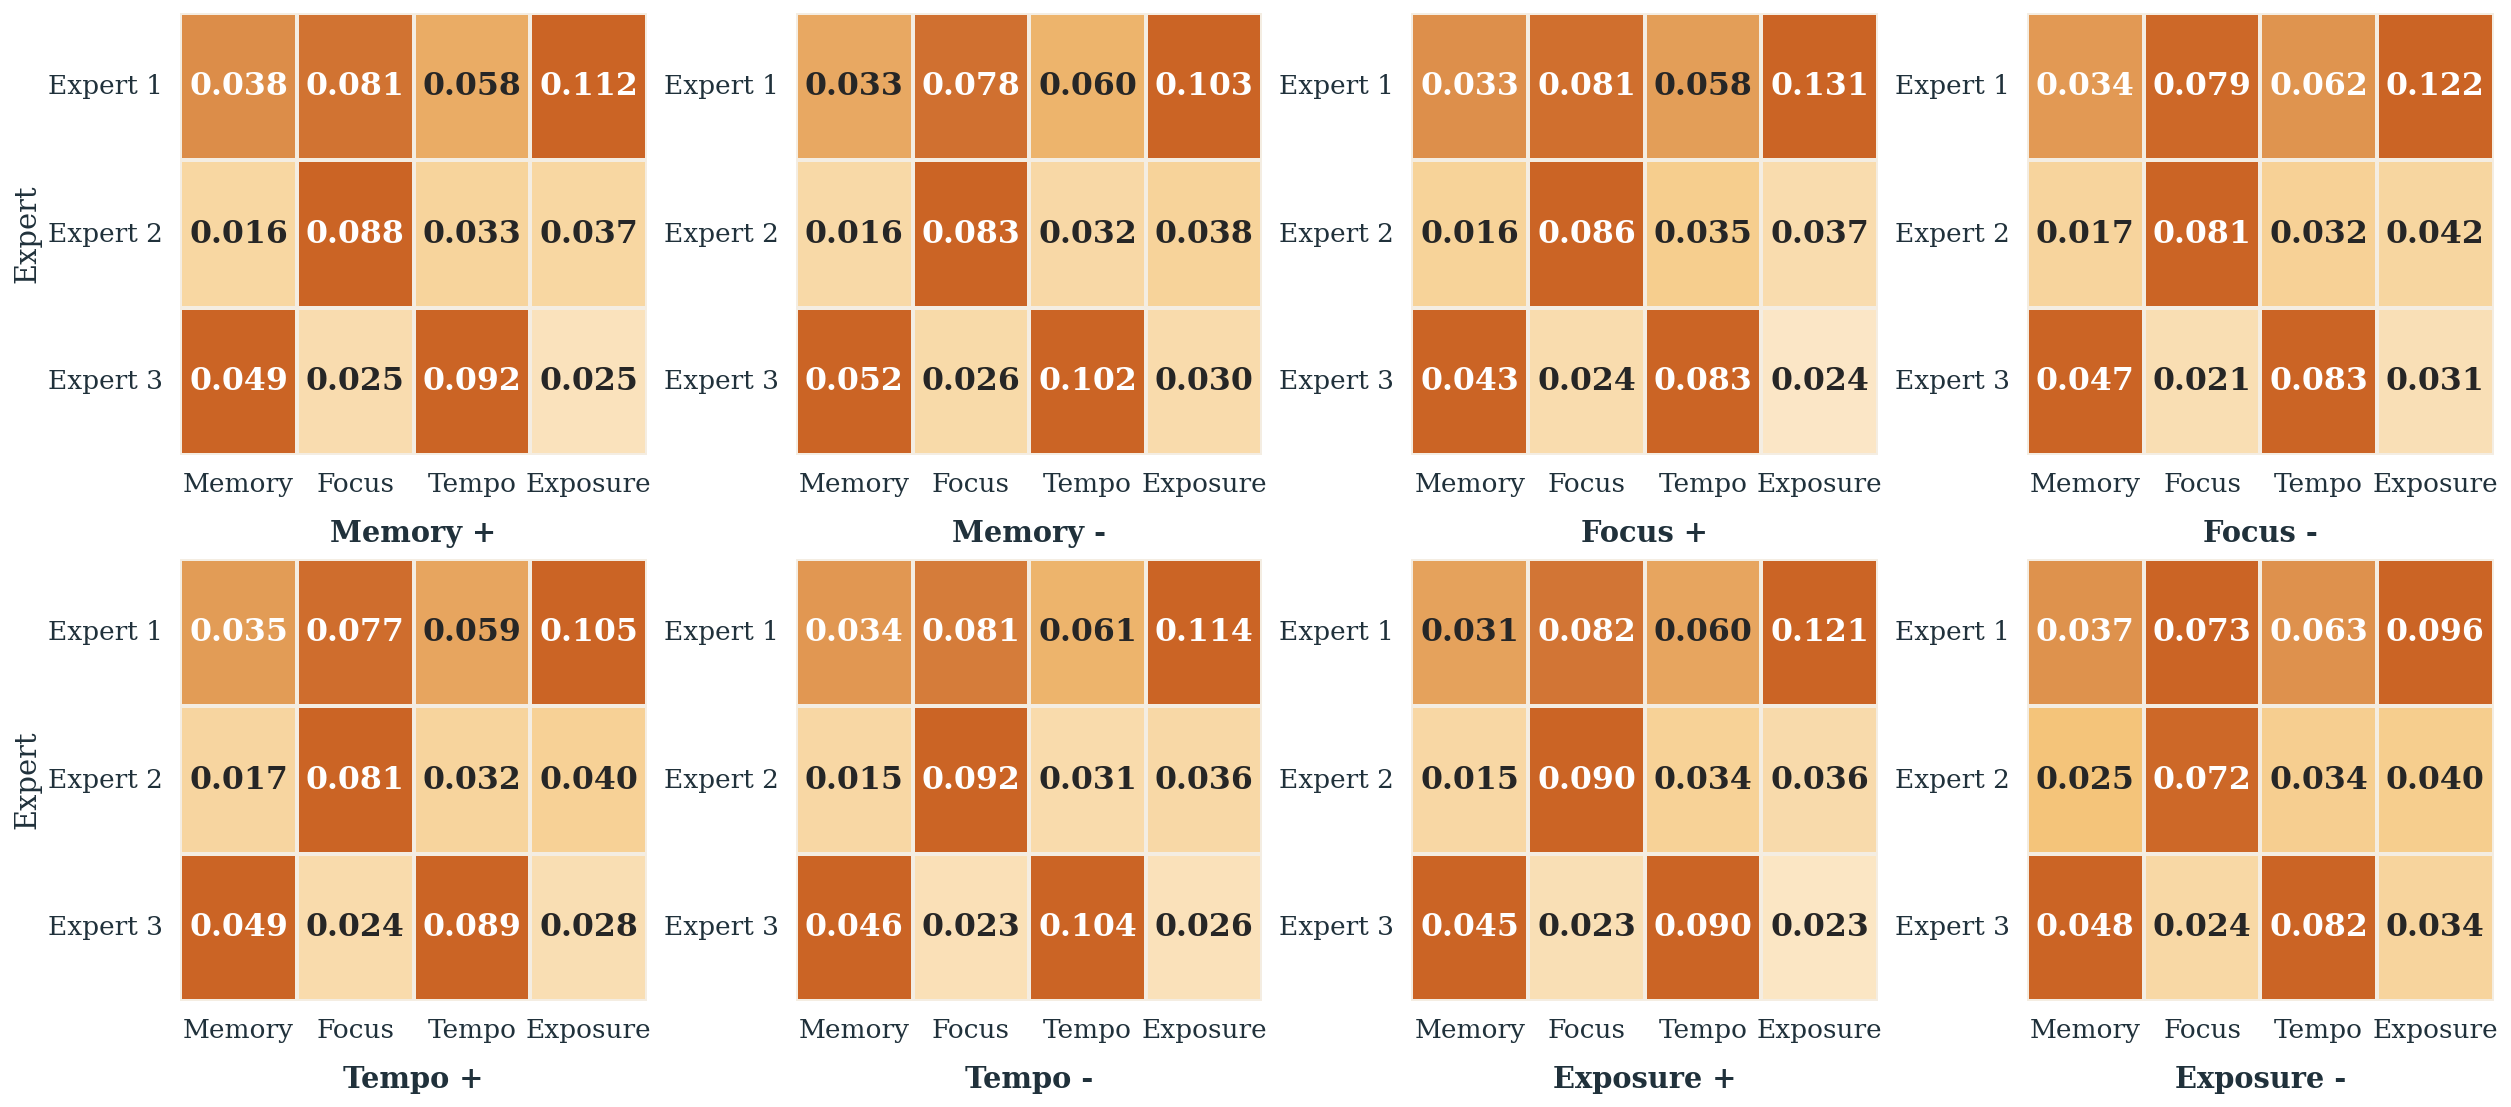

Saved /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_KuaiRecLargeStrictPosV2_0_2_macro_cases.pdf


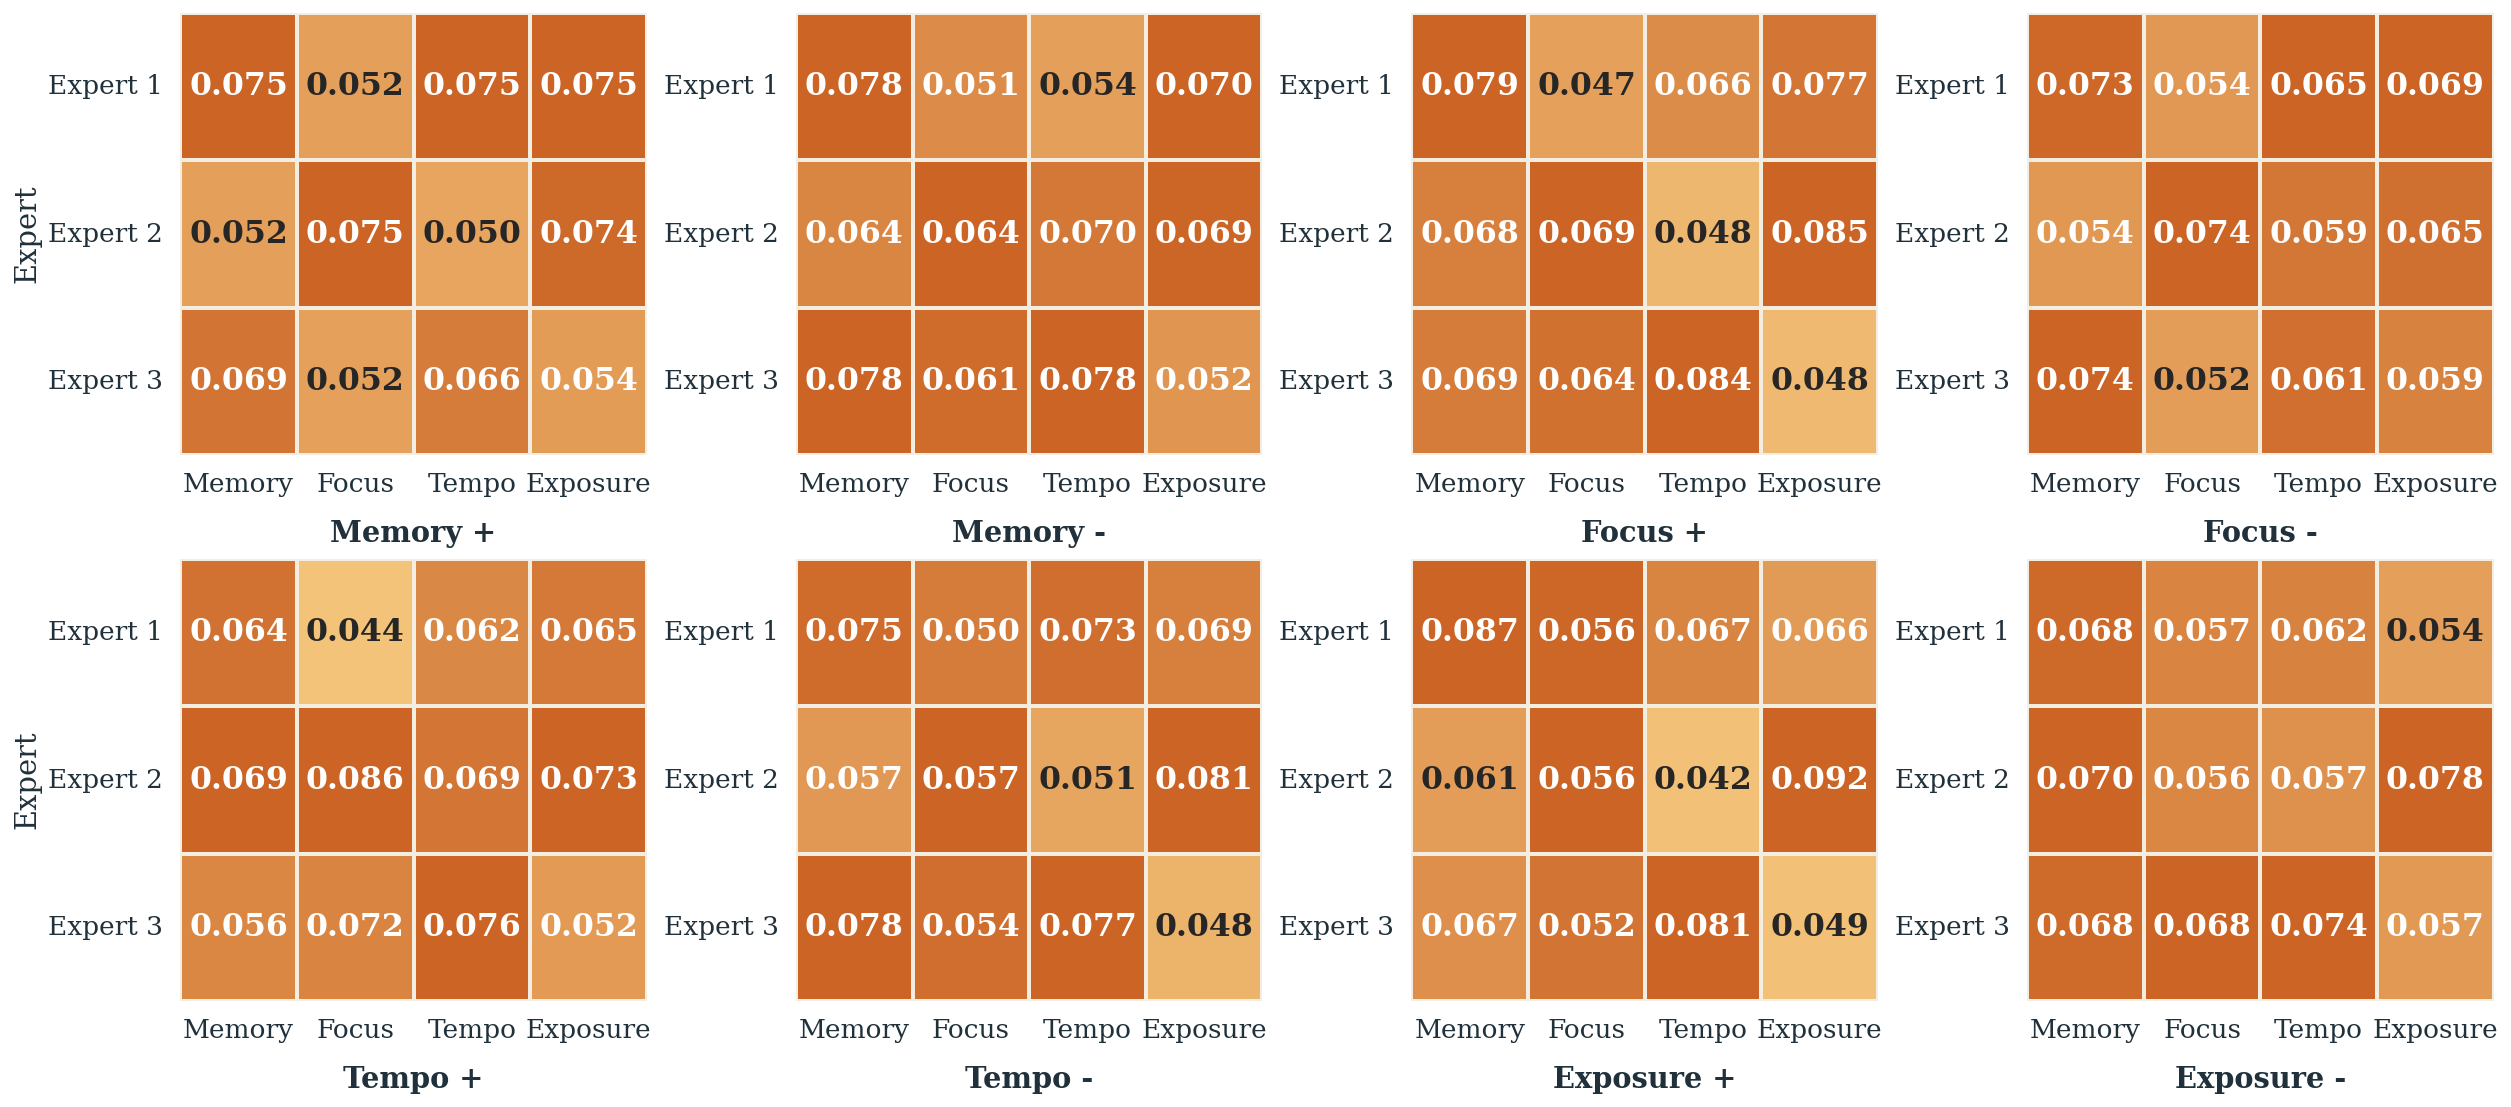

Saved /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_macro_cases.pdf
Saved files:
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_KuaiRecLargeStrictPosV2_0_2_macro_cases.pdf
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_macro_cases.pdf


In [3]:
repo_root = _repo_root() if callable(_repo_root) else _repo_root
appendix_dir = repo_root / 'writing' / 'ACM_template' / 'figures' / 'appendix'
appendix_dir.mkdir(parents=True, exist_ok=True)

saved_paths = []
for dataset in plot_datasets:
    case_labels = macro_case_labels_by_dataset.get(dataset, [])
    if not case_labels:
        print(f'Skip {dataset}: no macro case panels available')
        continue

    ncols = 4
    nrows = max(1, int(np.ceil(len(case_labels) / ncols)))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4.8, nrows * 4.2),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for idx, label in enumerate(case_labels):
        draw_compact_case_heatmap(
            axes[idx],
            macro_case_panels_by_dataset[dataset][label],
            case_display_name(label),
            show_ylabel=(idx % ncols == 0),
            annot_size=17.5,
            label_size=16.0,
            tick_size=14.6,
        )

    for idx in range(len(case_labels), len(axes)):
        axes[idx].axis('off')

    out_path = appendix_dir / f"a05_{dataset.replace('.', '_').replace('-', '_')}_macro_cases.pdf"
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    saved_paths.append(out_path)
    print(f'Saved {out_path}')

print('Saved files:')
for path in saved_paths:
    print(path)

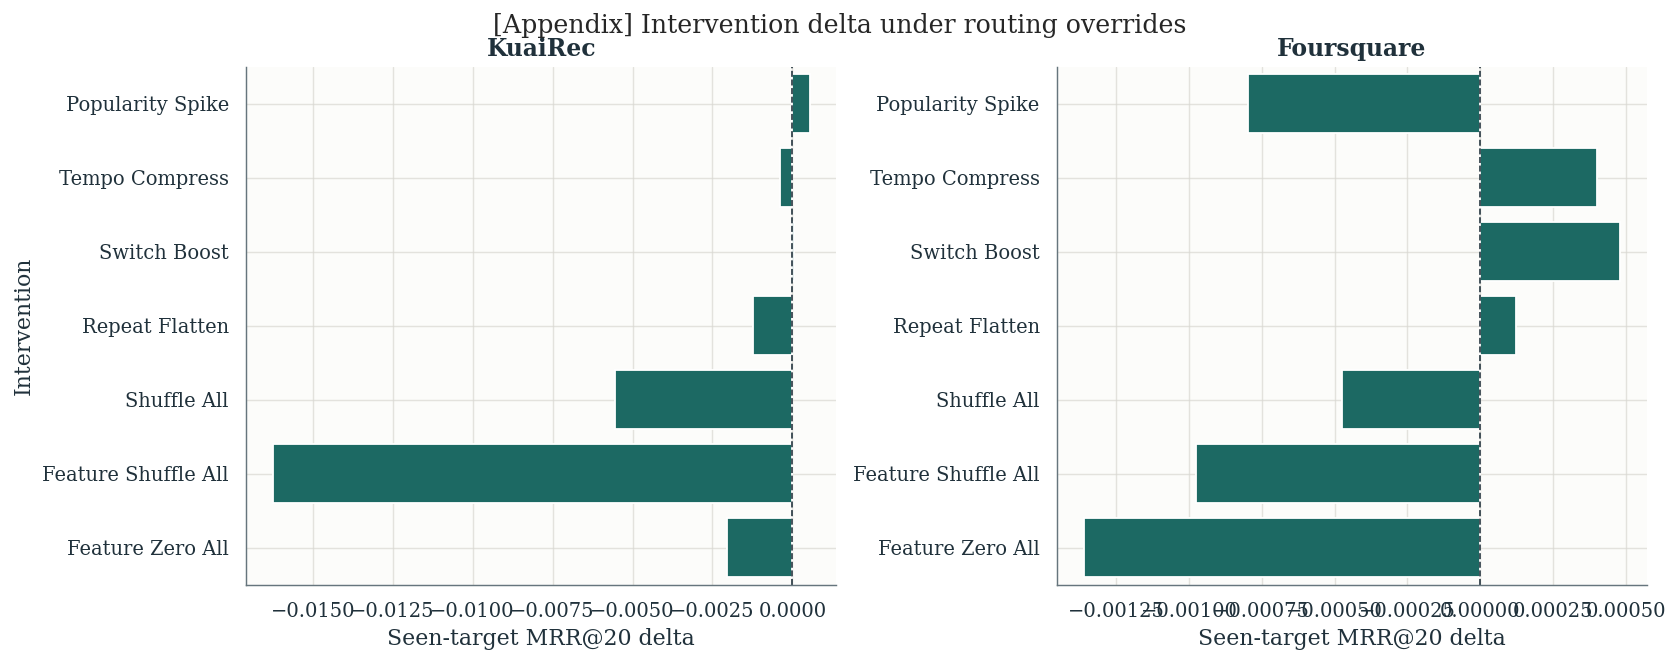

In [4]:
# ── [→ Appendix] Intervention delta: performance change under forced routing ──
plot_delta_df = delta_df[delta_df['intervention_label'].isin(TARGETED_INTERVENTION_ORDER)].copy()
if plot_delta_df is not None and len(plot_delta_df) > 0:
    apply_style()
    fig, axes = plt.subplots(1, len(plot_datasets), figsize=(12.8, 4.8), constrained_layout=True)
    if len(plot_datasets) == 1:
        axes = [axes]

    for idx, dataset in enumerate(plot_datasets):
        ax = axes[idx]
        sub = intervention_subset(dataset).copy()
        order = [label for label in TARGETED_INTERVENTION_ORDER if label in sub['intervention_label'].astype(str).tolist()]
        order = list(reversed(order))
        sns.barplot(
            data=sub,
            y='intervention_label',
            x='delta',
            order=order,
            color=PALETTE['route'],
            ax=ax,
        )
        ax.axvline(0, color=PALETTE['ink'], linewidth=0.9, linestyle='--')
        ax.set_title(dataset_label(dataset), fontsize=13.0)
        ax.set_xlabel('Seen-target MRR@20 delta', fontsize=12.2)
        ax.set_ylabel('Intervention' if idx == 0 else '', fontsize=12.2)
        ax.tick_params(axis='x', labelsize=10.8)
        ax.tick_params(axis='y', labelsize=10.8)
        clean_axes(ax)

    fig.suptitle('[Appendix] Intervention delta under routing overrides', fontsize=14.0, y=1.03)
    plt.show()
else:
    print('delta_df is empty — fill q5_intervention_summary.csv to generate this figure.')

## Sorted 8-case permissive gallery

Build paper-candidate views for the corrected FILTERFIX bundles:

- stage-average family routing heatmaps for both datasets
- full `average + macro + mid + micro` grid with a shared sorted case order per dataset
- summary table with stage-average target-family share and `test_seen_mrr20`

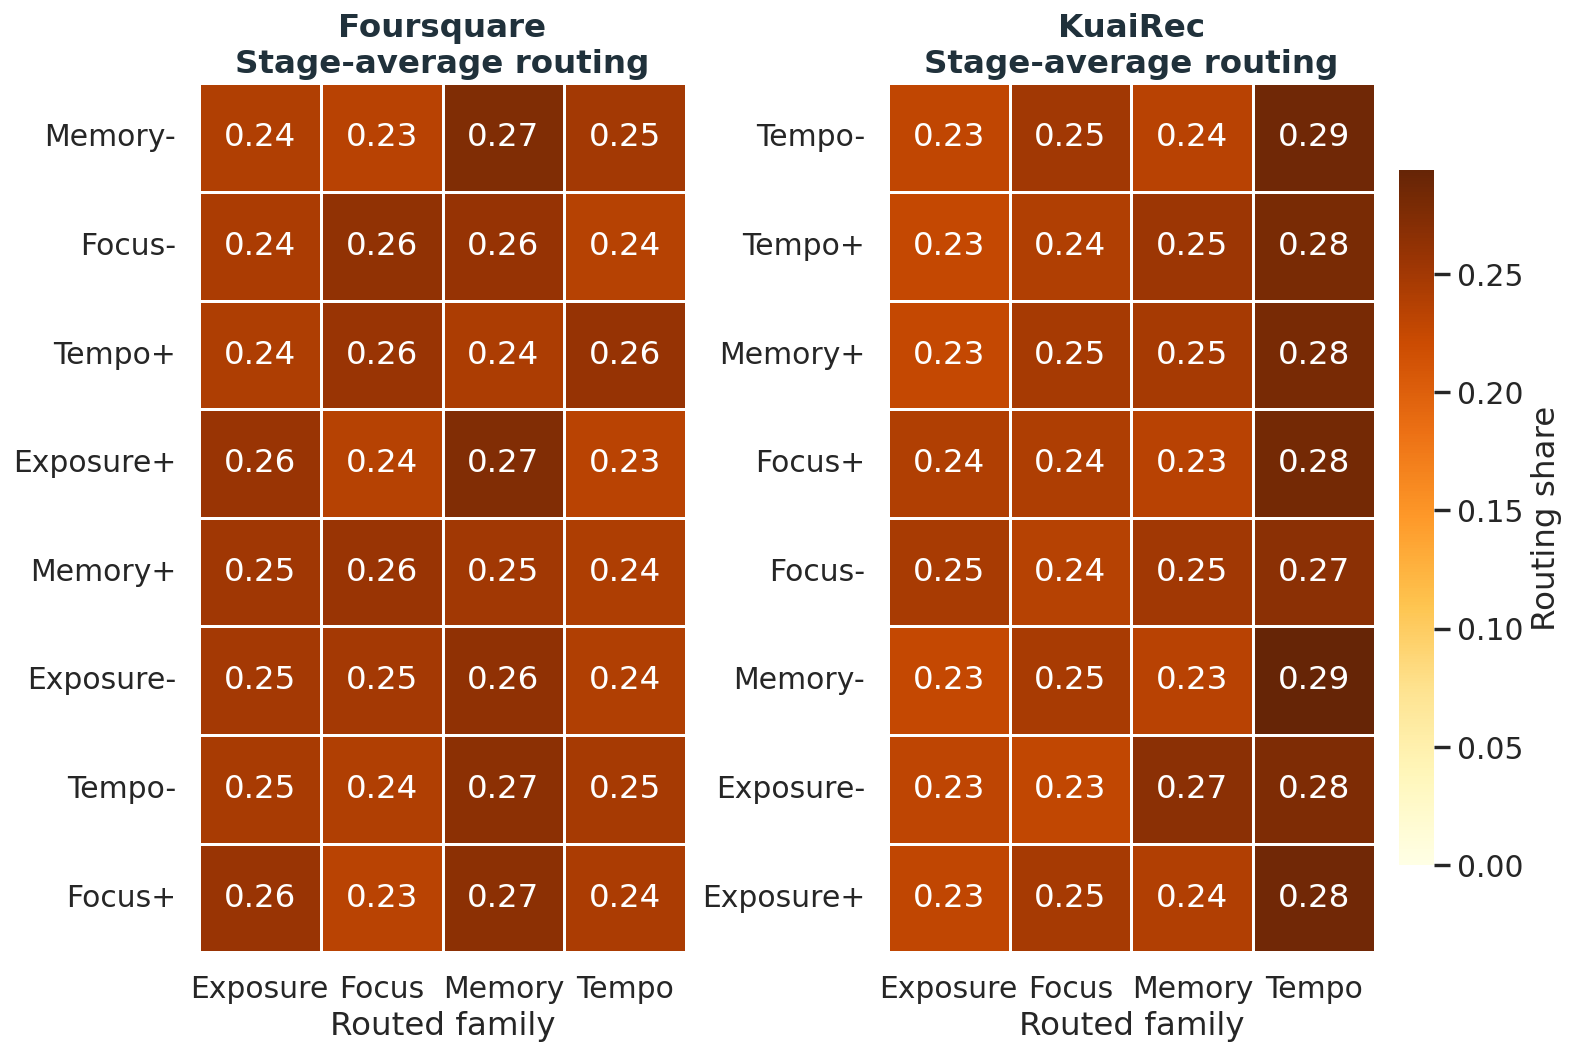

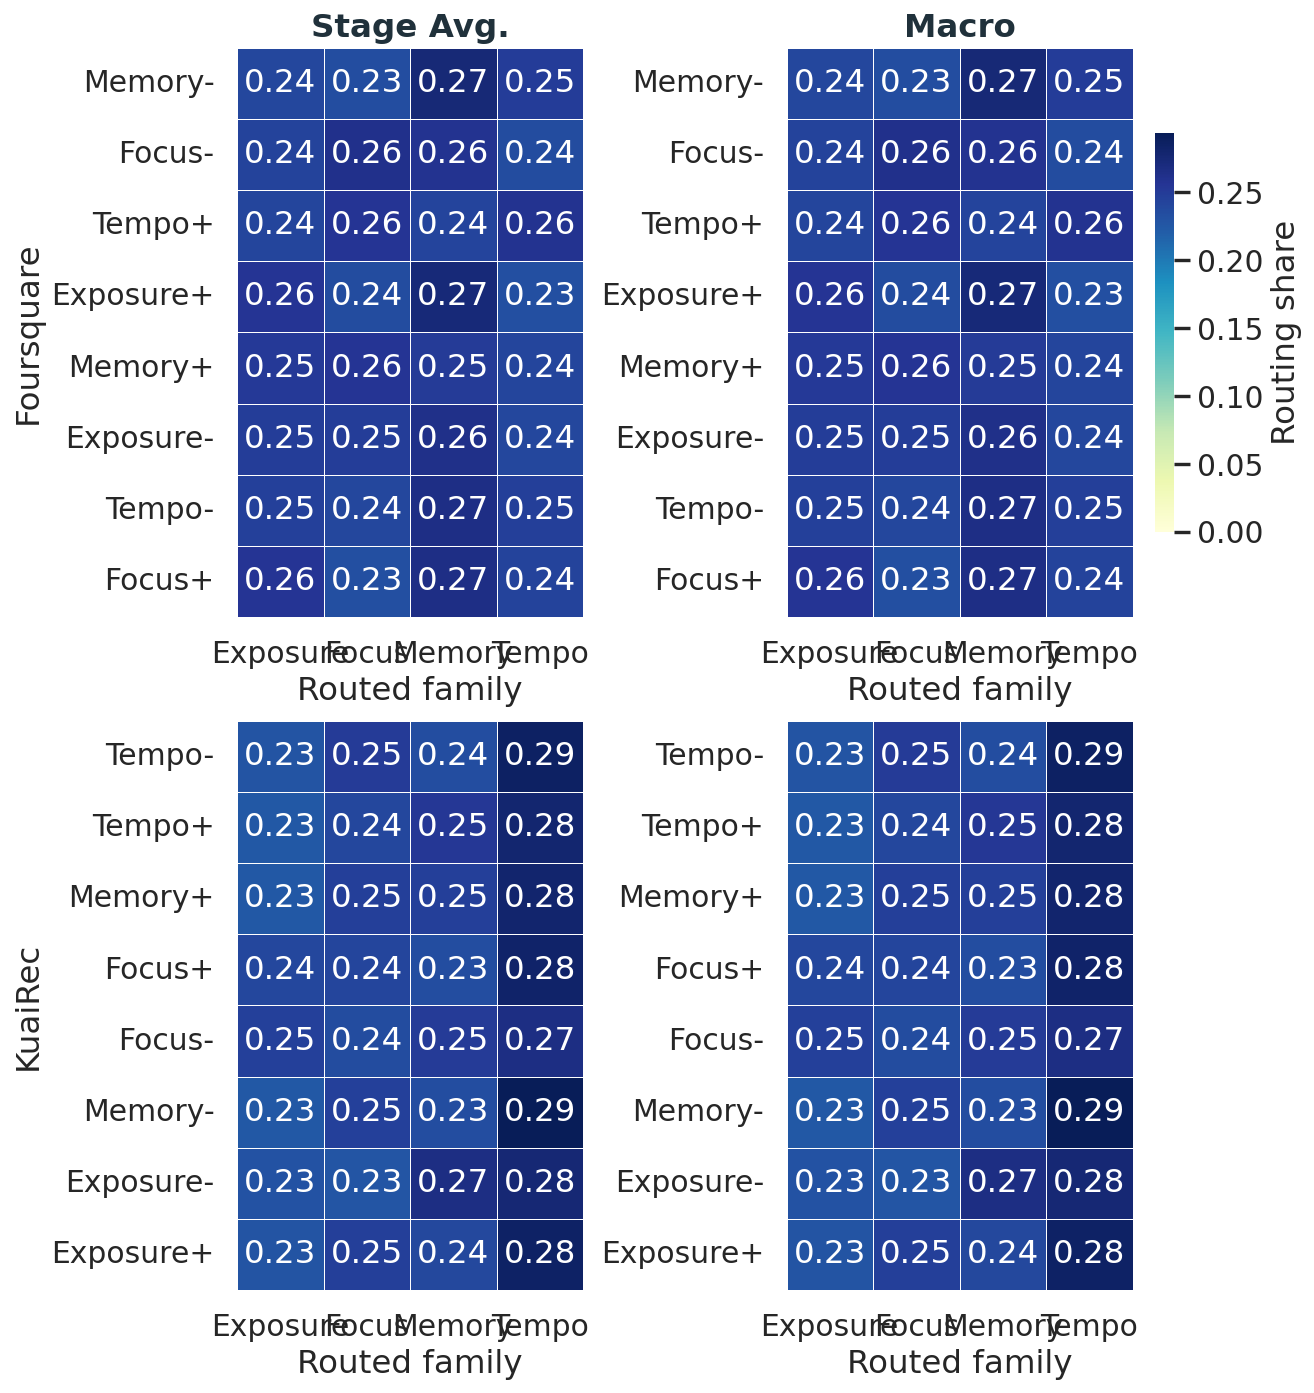

,dataset_label,sort_rank,case_label,target_stage_avg_share,macro_target_share,test_seen_mrr20,test_seen_ndcg20,test_seen_hit10
0,Foursquare,1,Memory-,0.274378,0.274378,0.117166,0.163476,0.275862
1,Foursquare,2,Focus-,0.261714,0.261714,0.178257,0.250298,0.361446
2,Foursquare,3,Tempo+,0.258897,0.258897,0.147428,0.220909,0.373134
3,Foursquare,4,Exposure+,0.256132,0.256132,0.289412,0.367009,0.556604
4,Foursquare,5,Memory+,0.251007,0.251007,0.279587,0.348976,0.505618
5,Foursquare,6,Exposure-,0.248282,0.248282,0.166200,0.207288,0.304878
6,Foursquare,7,Tempo-,0.247548,0.247548,0.298621,0.365576,0.533981
7,Foursquare,8,Focus+,0.233672,0.233672,0.208429,0.271231,0.422222
8,KuaiRec,1,Tempo-,0.285925,0.285925,0.951613,0.955836,0.967742
9,KuaiRec,2,Tempo+,0.279903,0.279903,0.801905,0.814644,0.840909


Missing stage diagnostics in current FILTERFIX exports: mid, micro
Saved figures:
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_q5_permissive_stage_average_sorted.png
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_q5_permissive_stage_average_sorted.pdf
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_q5_permissive_sorted_avg_macro.png
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_q5_permissive_sorted_avg_macro.pdf
Saved summaries:
/workspace/FeaturedMoE/writing/260419_real_final_exp/generated/q5_permissive_stage_average_sorted_summary.csv
/workspace/FeaturedMoE/writing/260419_real_final_exp/generated/q5_permissive_stage_average_sorted_summary.md
/workspace/FeaturedMoE/writing/260419_real_final_exp/generated/q5_permissive_stage_coverage_note.md


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

REPO_ROOT = Path('/workspace/FeaturedMoE')
Q5_FILTERFIX_BUNDLES = {
    'foursquare': REPO_ROOT / 'experiments/run/artifacts/logs/real_final_ablation/q5/case_eval_rerun/Q5_FOURSQUARE_BEHAVIOR_GUIDED_R01_S1_FILTERFIX_20260420/tables',
    'KuaiRecLargeStrictPosV2_0.2': REPO_ROOT / 'experiments/run/artifacts/logs/real_final_ablation/q5/case_eval_rerun/Q5_KUAIRECLARGESTRICTPOSV2_0_2_BEHAVIOR_GUIDED_R01_S1_FILTERFIX_20260420/tables',
}
Q5_DATASET_LABELS = {
    'foursquare': 'Foursquare',
    'KuaiRecLargeStrictPosV2_0.2': 'KuaiRec',
}
Q5_FAMILY_ORDER = ['Exposure', 'Focus', 'Memory', 'Tempo']
Q5_STAGE_ORDER = ['macro', 'mid', 'micro']
Q5_STAGE_TITLE = {'avg': 'Stage Avg.', 'macro': 'Macro', 'mid': 'Mid', 'micro': 'Micro'}
Q5_POLARITY_SYMBOL = {'plus': '+', 'minus': '-'}
Q5_APPENDIX_DIR = REPO_ROOT / 'writing/ACM_template/figures/appendix'
Q5_GENERATED_DIR = REPO_ROOT / 'writing/260419_real_final_exp/generated'
Q5_APPENDIX_DIR.mkdir(parents=True, exist_ok=True)
Q5_GENERATED_DIR.mkdir(parents=True, exist_ok=True)


def load_q5_permissive_tables():
    routing_frames = []
    performance_frames = []
    for dataset, table_dir in Q5_FILTERFIX_BUNDLES.items():
        routing = pd.read_csv(table_dir / 'case_eval_routing_profile.csv')
        routing = routing.loc[
            (routing['scope'] == 'tier_group')
            & (routing['tier'] == 'permissive')
            & (routing['status'] == 'ok')
            & (routing['eval_split'] == 'test')
            & routing['selected_family'].notna()
            & routing['selected_polarity'].notna()
        ].copy()
        routing['dataset'] = dataset
        routing['selected_family'] = routing['selected_family'].str.lower()
        routing['selected_polarity'] = routing['selected_polarity'].str.lower()
        routing['stage_name'] = routing['stage_name'].str.lower()
        routing['routed_family'] = routing['routed_family'].str.title()
        routing['case_key'] = routing['selected_family'] + '_' + routing['selected_polarity']
        routing['case_label'] = (
            routing['selected_family'].str.title()
            + routing['selected_polarity'].map(Q5_POLARITY_SYMBOL)
        )
        routing['target_family'] = routing['selected_family'].str.title()
        routing_frames.append(routing)

        performance = pd.read_csv(table_dir / 'case_eval_performance.csv')
        performance = performance.loc[
            (performance['scope'] == 'tier_group')
            & (performance['tier'] == 'permissive')
            & (performance['status'] == 'ok')
            & performance['selected_family'].notna()
            & performance['selected_polarity'].notna()
        ].copy()
        performance['dataset'] = dataset
        performance['selected_family'] = performance['selected_family'].str.lower()
        performance['selected_polarity'] = performance['selected_polarity'].str.lower()
        performance['case_key'] = performance['selected_family'] + '_' + performance['selected_polarity']
        performance['case_label'] = (
            performance['selected_family'].str.title()
            + performance['selected_polarity'].map(Q5_POLARITY_SYMBOL)
        )
        performance_frames.append(
            performance[
                ['dataset', 'case_key', 'case_label', 'test_seen_mrr20', 'test_seen_ndcg20', 'test_seen_hit10']
            ].drop_duplicates()
        )

    return pd.concat(routing_frames, ignore_index=True), pd.concat(performance_frames, ignore_index=True)


q5_perm_routing_df, q5_perm_perf_df = load_q5_permissive_tables()
q5_available_stages = [
    stage for stage in Q5_STAGE_ORDER if stage in set(q5_perm_routing_df['stage_name'].dropna().unique())
]
q5_missing_stages = [stage for stage in Q5_STAGE_ORDER if stage not in q5_available_stages]

q5_target_df = q5_perm_routing_df.loc[
    q5_perm_routing_df['target_family'] == q5_perm_routing_df['routed_family']
].copy()

q5_target_stage_summary = (
    q5_target_df.groupby(['dataset', 'case_key', 'case_label', 'stage_name'], as_index=False)['usage_share']
    .mean()
    .rename(columns={'usage_share': 'target_family_share'})
)

q5_stage_average_summary = (
    q5_target_stage_summary.groupby(['dataset', 'case_key', 'case_label'], as_index=False)['target_family_share']
    .mean()
    .rename(columns={'target_family_share': 'target_stage_avg_share'})
)

q5_stage_pivot = (
    q5_target_stage_summary.pivot(index=['dataset', 'case_key', 'case_label'], columns='stage_name', values='target_family_share')
    .reset_index()
)
q5_stage_pivot.columns.name = None

q5_sorted_summary = (
    q5_stage_average_summary
    .merge(q5_stage_pivot, on=['dataset', 'case_key', 'case_label'], how='left')
    .merge(q5_perm_perf_df, on=['dataset', 'case_key', 'case_label'], how='left')
)
q5_sorted_summary['dataset_label'] = q5_sorted_summary['dataset'].map(Q5_DATASET_LABELS)
q5_sorted_summary = q5_sorted_summary.sort_values(
    ['dataset_label', 'target_stage_avg_share', 'test_seen_mrr20'],
    ascending=[True, False, False],
).reset_index(drop=True)
q5_sorted_summary['sort_rank'] = q5_sorted_summary.groupby('dataset').cumcount() + 1

q5_case_order_by_dataset = {
    dataset: sub['case_label'].tolist()
    for dataset, sub in q5_sorted_summary.groupby('dataset', sort=False)
}


def build_case_panel(routing_df, dataset, stage_key):
    sub = routing_df.loc[routing_df['dataset'] == dataset].copy()
    if stage_key == 'avg':
        panel_df = sub.groupby(['case_label', 'routed_family'], as_index=False)['usage_share'].mean()
    else:
        panel_df = sub.loc[sub['stage_name'] == stage_key, ['case_label', 'routed_family', 'usage_share']].copy()
    panel = panel_df.pivot(index='case_label', columns='routed_family', values='usage_share')
    panel = panel.reindex(index=q5_case_order_by_dataset[dataset], columns=Q5_FAMILY_ORDER)
    return panel.fillna(0.0)


q5_avg_panels = {dataset: build_case_panel(q5_perm_routing_df, dataset, 'avg') for dataset in Q5_FILTERFIX_BUNDLES}
q5_grid_stage_keys = ['avg', *q5_available_stages]
q5_grid_panels = {
    dataset: {stage_key: build_case_panel(q5_perm_routing_df, dataset, stage_key) for stage_key in q5_grid_stage_keys}
    for dataset in Q5_FILTERFIX_BUNDLES
}
q5_global_vmax = max(panel.to_numpy().max() for panel in q5_avg_panels.values())
q5_grid_vmax = max(
    panel.to_numpy().max()
    for panels in q5_grid_panels.values()
    for panel in panels.values()
)

sns.set_theme(style='white', context='talk')

fig_avg, axes_avg = plt.subplots(1, 2, figsize=(12, 8), constrained_layout=True)
for ax, dataset in zip(axes_avg, Q5_FILTERFIX_BUNDLES):
    panel = q5_avg_panels[dataset]
    sns.heatmap(
        panel,
        ax=ax,
        cmap='YlOrBr',
        vmin=0,
        vmax=q5_global_vmax,
        annot=True,
        fmt='.2f',
        linewidths=0.6,
        linecolor='white',
        cbar=ax is axes_avg[-1],
        cbar_kws={'shrink': 0.8, 'label': 'Routing share'},
    )
    ax.set_title(f"{Q5_DATASET_LABELS[dataset]}\nStage-average routing")
    ax.set_xlabel('Routed family')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

avg_png = Q5_APPENDIX_DIR / 'a05_q5_permissive_stage_average_sorted.png'
avg_pdf = Q5_APPENDIX_DIR / 'a05_q5_permissive_stage_average_sorted.pdf'
fig_avg.savefig(avg_png, dpi=220, bbox_inches='tight')
fig_avg.savefig(avg_pdf, bbox_inches='tight')
plt.show()

fig_grid, axes_grid = plt.subplots(
    len(Q5_FILTERFIX_BUNDLES),
    len(q5_grid_stage_keys),
    figsize=(5 * len(q5_grid_stage_keys), 5.3 * len(Q5_FILTERFIX_BUNDLES)),
    constrained_layout=True,
    squeeze=False,
)
for row_idx, dataset in enumerate(Q5_FILTERFIX_BUNDLES):
    for col_idx, stage_key in enumerate(q5_grid_stage_keys):
        ax = axes_grid[row_idx, col_idx]
        panel = q5_grid_panels[dataset][stage_key]
        sns.heatmap(
            panel,
            ax=ax,
            cmap='YlGnBu',
            vmin=0,
            vmax=q5_grid_vmax,
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            linecolor='white',
            cbar=(row_idx == 0 and col_idx == len(q5_grid_stage_keys) - 1),
            cbar_kws={'shrink': 0.7, 'label': 'Routing share'},
        )
        if row_idx == 0:
            ax.set_title(Q5_STAGE_TITLE.get(stage_key, stage_key.title()))
        if col_idx == 0:
            ax.set_ylabel(Q5_DATASET_LABELS[dataset])
        else:
            ax.set_ylabel('')
        ax.set_xlabel('Routed family')
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0)

grid_suffix = '_'.join(q5_grid_stage_keys)
grid_png = Q5_APPENDIX_DIR / f'a05_q5_permissive_sorted_{grid_suffix}.png'
grid_pdf = Q5_APPENDIX_DIR / f'a05_q5_permissive_sorted_{grid_suffix}.pdf'
fig_grid.savefig(grid_png, dpi=220, bbox_inches='tight')
fig_grid.savefig(grid_pdf, bbox_inches='tight')
plt.show()

q5_summary_cols = ['dataset_label', 'sort_rank', 'case_label', 'target_stage_avg_share', *q5_available_stages, 'test_seen_mrr20', 'test_seen_ndcg20', 'test_seen_hit10']
q5_sorted_summary_export = q5_sorted_summary[q5_summary_cols].rename(
    columns={stage: f'{stage}_target_share' for stage in q5_available_stages}
)
summary_csv = Q5_GENERATED_DIR / 'q5_permissive_stage_average_sorted_summary.csv'
summary_md = Q5_GENERATED_DIR / 'q5_permissive_stage_average_sorted_summary.md'
stage_note_md = Q5_GENERATED_DIR / 'q5_permissive_stage_coverage_note.md'
q5_sorted_summary_export.to_csv(summary_csv, index=False)
summary_md.write_text(q5_sorted_summary_export.to_markdown(index=False) + '\n', encoding='utf-8')
if q5_missing_stages:
    stage_note_md.write_text(
        'Available stages in current FILTERFIX router diagnostics: ' + ', '.join(q5_available_stages) + '\n'
        + 'Missing stages: ' + ', '.join(q5_missing_stages) + '\n',
        encoding='utf-8',
    )
else:
    stage_note_md.write_text(
        'Available stages in current FILTERFIX router diagnostics: ' + ', '.join(q5_available_stages) + '\n',
        encoding='utf-8',
    )

display(q5_sorted_summary_export)
if q5_missing_stages:
    print('Missing stage diagnostics in current FILTERFIX exports:', ', '.join(q5_missing_stages))
print('Saved figures:')
print(avg_png)
print(avg_pdf)
print(grid_png)
print(grid_pdf)
print('Saved summaries:')
print(summary_csv)
print(summary_md)
print(stage_note_md)

### Pure vs permissive, top1 post-selection, and expert deviation

The appendix gallery above uses family-level soft routing mass, which can look flatter than post-selection behavior.

This section compares `pure` and `permissive` side by side using three stronger views:

- family-level soft routing share
- family-level post-selection top1 share
- expert-level top1-rate delta against the dataset-wide original split average

Note: current FILTERFIX exports contain `top1_count`, not top-k selection counts, so the post-selection view below uses top1 as the sharpest available signal in the exported diagnostics.

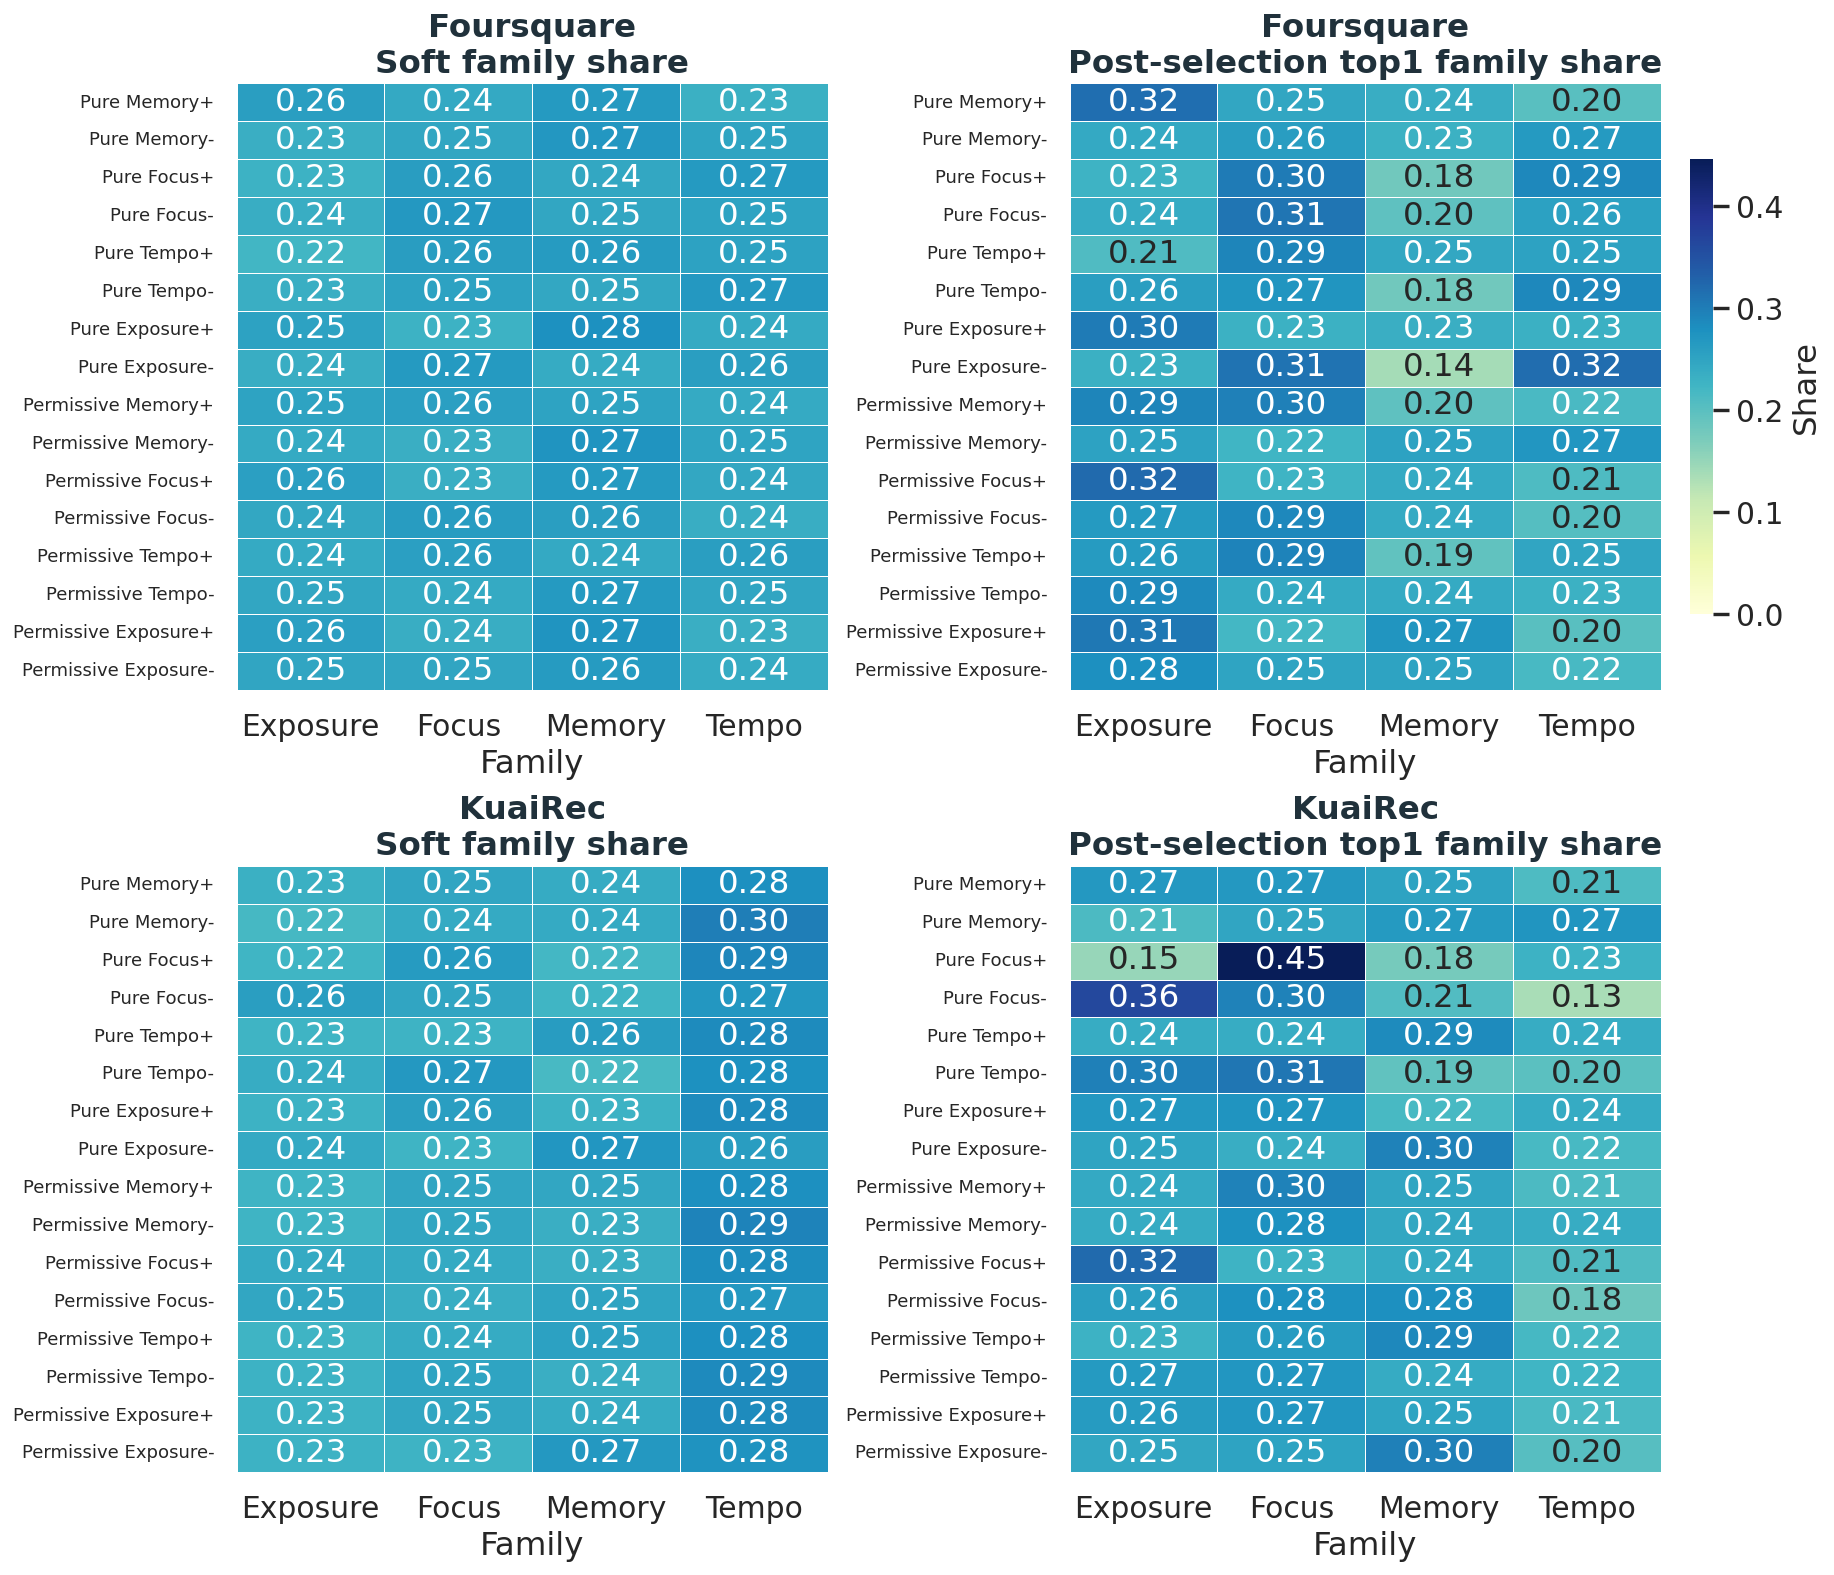

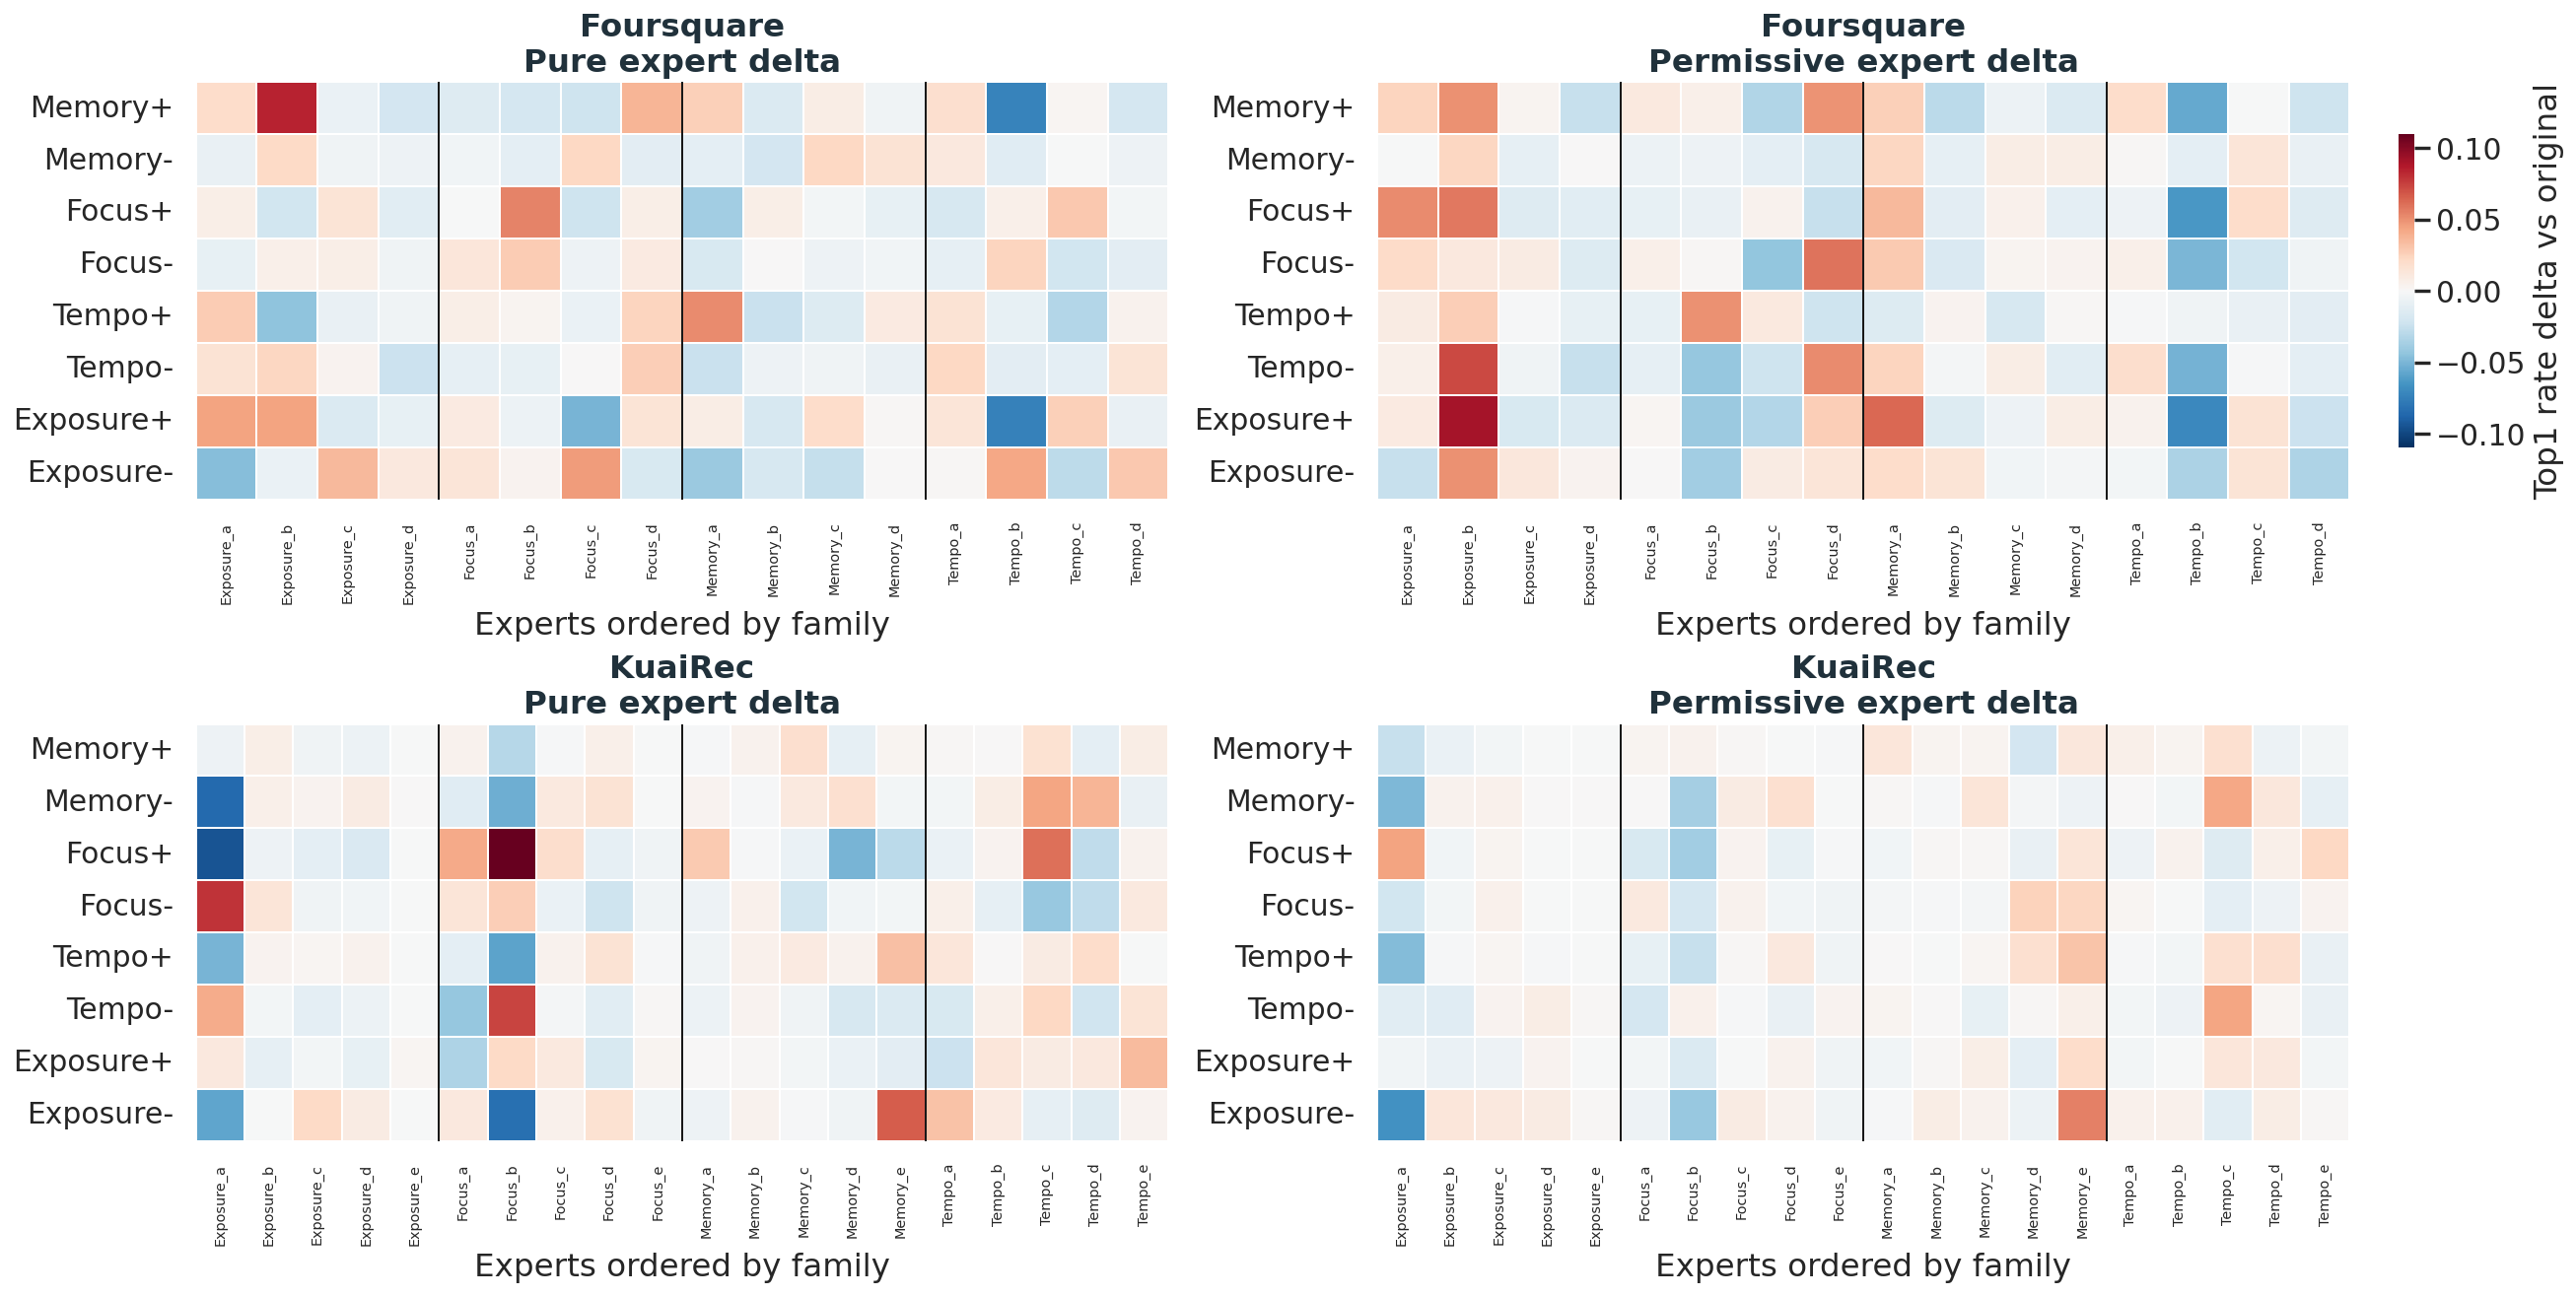

,dataset_label,tier_label,case_label,soft_target_share,top1_target_share,target_gain_top1_minus_soft,total_top1_assignments,test_seen_mrr20,test_seen_ndcg20,test_seen_hit10
0,Foursquare,Permissive,Memory+,0.251007,0.196660,-0.054346,539.0,0.279587,0.348976,0.505618
1,Foursquare,Permissive,Memory-,0.274378,0.252768,-0.021610,542.0,0.117166,0.163476,0.275862
2,Foursquare,Permissive,Focus+,0.233672,0.226306,-0.007366,517.0,0.208429,0.271231,0.422222
3,Foursquare,Permissive,Focus-,0.261714,0.287918,0.026204,778.0,0.178257,0.250298,0.361446
4,Foursquare,Permissive,Tempo+,0.258897,0.248485,-0.010412,330.0,0.147428,0.220909,0.373134
5,Foursquare,Permissive,Tempo-,0.247548,0.230415,-0.017134,651.0,0.298621,0.365576,0.533981
6,Foursquare,Permissive,Exposure+,0.256132,0.305319,0.049187,940.0,0.289412,0.367009,0.556604
7,Foursquare,Permissive,Exposure-,0.248282,0.280172,0.031891,464.0,0.166200,0.207288,0.304878
8,Foursquare,Pure,Memory+,0.266165,0.236559,-0.029606,1209.0,0.326380,0.395579,0.558442
9,Foursquare,Pure,Memory-,0.268305,0.230769,-0.037536,1365.0,0.202720,0.256536,0.333333


Saved figures:
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_q5_pure_permissive_soft_vs_top1_family.png
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_q5_pure_permissive_soft_vs_top1_family.pdf
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_q5_pure_permissive_expert_top1_delta.png
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_q5_pure_permissive_expert_top1_delta.pdf
Saved summaries:
/workspace/FeaturedMoE/writing/260419_real_final_exp/generated/q5_pure_permissive_soft_vs_top1_summary.csv
/workspace/FeaturedMoE/writing/260419_real_final_exp/generated/q5_pure_permissive_soft_vs_top1_summary.md
/workspace/FeaturedMoE/writing/260419_real_final_exp/generated/q5_top1_postselection_note.md


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

Q5_TIER_ORDER = ['pure', 'permissive']
Q5_TIER_LABELS = {'pure': 'Pure', 'permissive': 'Permissive'}
Q5_CASE_ORDER = [
    'memory_plus',
    'memory_minus',
    'focus_plus',
    'focus_minus',
    'tempo_plus',
    'tempo_minus',
    'exposure_plus',
    'exposure_minus',
]
Q5_CASE_LABELS_SHORT = {
    'memory_plus': 'Memory+',
    'memory_minus': 'Memory-',
    'focus_plus': 'Focus+',
    'focus_minus': 'Focus-',
    'tempo_plus': 'Tempo+',
    'tempo_minus': 'Tempo-',
    'exposure_plus': 'Exposure+',
    'exposure_minus': 'Exposure-',
}


def load_q5_top1_tables():
    expert_frames = []
    routing_frames = []
    performance_frames = []
    for dataset, table_dir in Q5_FILTERFIX_BUNDLES.items():
        expert = pd.read_csv(table_dir / 'case_eval_expert_profile.csv')
        expert = expert.loc[
            (expert['status'] == 'ok')
            & (expert['eval_split'] == 'test')
            & (expert['stage_name'].astype(str).str.lower() == 'macro')
            & (
                (expert['scope'] == 'original')
                | (
                    (expert['scope'] == 'tier_group')
                    & expert['tier'].isin(Q5_TIER_ORDER)
                    & expert['selected_family'].notna()
                    & expert['selected_polarity'].notna()
                )
            )
        ].copy()
        expert['dataset'] = dataset
        expert['expert_family'] = expert['expert_family'].astype(str).str.lower()
        expert['expert_name'] = expert['expert_name'].astype(str)
        expert['scope'] = expert['scope'].astype(str)
        expert['tier'] = expert['tier'].astype(str).str.lower()
        expert['selected_family'] = expert['selected_family'].astype(str).str.lower()
        expert['selected_polarity'] = expert['selected_polarity'].astype(str).str.lower()
        expert['case_key'] = expert['selected_family'] + '_' + expert['selected_polarity']
        expert['case_label'] = expert['case_key'].map(Q5_CASE_LABELS_SHORT)
        expert_frames.append(expert)

        routing = pd.read_csv(table_dir / 'case_eval_routing_profile.csv')
        routing = routing.loc[
            (routing['status'] == 'ok')
            & (routing['scope'] == 'tier_group')
            & (routing['tier'].isin(Q5_TIER_ORDER))
            & (routing['eval_split'] == 'test')
            & (routing['stage_name'].astype(str).str.lower() == 'macro')
            & routing['selected_family'].notna()
            & routing['selected_polarity'].notna()
        ].copy()
        routing['dataset'] = dataset
        routing['tier'] = routing['tier'].astype(str).str.lower()
        routing['selected_family'] = routing['selected_family'].astype(str).str.lower()
        routing['selected_polarity'] = routing['selected_polarity'].astype(str).str.lower()
        routing['routed_family'] = routing['routed_family'].astype(str).str.title()
        routing['case_key'] = routing['selected_family'] + '_' + routing['selected_polarity']
        routing['case_label'] = routing['case_key'].map(Q5_CASE_LABELS_SHORT)
        routing_frames.append(routing)

        performance = pd.read_csv(table_dir / 'case_eval_performance.csv')
        performance = performance.loc[
            (performance['status'] == 'ok')
            & (performance['scope'] == 'tier_group')
            & (performance['tier'].isin(Q5_TIER_ORDER))
            & performance['selected_family'].notna()
            & performance['selected_polarity'].notna()
        ].copy()
        performance['dataset'] = dataset
        performance['tier'] = performance['tier'].astype(str).str.lower()
        performance['selected_family'] = performance['selected_family'].astype(str).str.lower()
        performance['selected_polarity'] = performance['selected_polarity'].astype(str).str.lower()
        performance['case_key'] = performance['selected_family'] + '_' + performance['selected_polarity']
        performance['case_label'] = performance['case_key'].map(Q5_CASE_LABELS_SHORT)
        performance_frames.append(
            performance[
                [
                    'dataset',
                    'tier',
                    'case_key',
                    'case_label',
                    'selected_family',
                    'test_seen_mrr20',
                    'test_seen_ndcg20',
                    'test_seen_hit10',
                ]
            ].drop_duplicates()
        )

    return (
        pd.concat(expert_frames, ignore_index=True),
        pd.concat(routing_frames, ignore_index=True),
        pd.concat(performance_frames, ignore_index=True),
    )


q5_top1_expert_df, q5_top1_routing_df, q5_top1_perf_df = load_q5_top1_tables()

q5_original_expert = q5_top1_expert_df.loc[q5_top1_expert_df['scope'] == 'original'].copy()
q5_original_expert['original_total_top1'] = q5_original_expert.groupby('dataset')['top1_count'].transform('sum')
q5_original_expert['original_top1_rate'] = (
    q5_original_expert['top1_count'] / q5_original_expert['original_total_top1']
)
q5_original_expert_rate = q5_original_expert[
    ['dataset', 'expert_name', 'expert_family', 'original_top1_rate']
].drop_duplicates()
q5_expert_order = {
    dataset: sub.sort_values(['expert_family', 'expert_index'])['expert_name'].tolist()
    for dataset, sub in q5_original_expert.groupby('dataset', sort=False)
}
q5_expert_family_lookup = (
    q5_original_expert[['dataset', 'expert_name', 'expert_family']]
    .drop_duplicates()
    .set_index(['dataset', 'expert_name'])['expert_family']
)

q5_case_expert = q5_top1_expert_df.loc[q5_top1_expert_df['scope'] == 'tier_group'].copy()
q5_case_expert['case_sort'] = pd.Categorical(q5_case_expert['case_key'], categories=Q5_CASE_ORDER, ordered=True)
q5_case_expert['total_top1_count'] = q5_case_expert.groupby(
    ['dataset', 'tier', 'case_key']
)['top1_count'].transform('sum')
q5_case_expert['top1_rate'] = q5_case_expert['top1_count'] / q5_case_expert['total_top1_count']
q5_case_expert = q5_case_expert.merge(
    q5_original_expert_rate,
    on=['dataset', 'expert_name', 'expert_family'],
    how='left',
)
q5_case_expert['top1_delta_vs_original'] = (
    q5_case_expert['top1_rate'] - q5_case_expert['original_top1_rate']
)
q5_case_expert['tier_case_label'] = (
    q5_case_expert['tier'].map(Q5_TIER_LABELS) + ' ' + q5_case_expert['case_label']
)

q5_soft_family = q5_top1_routing_df[
    ['dataset', 'tier', 'case_key', 'case_label', 'selected_family', 'routed_family', 'usage_share']
].copy()
q5_soft_family['tier_case_label'] = (
    q5_soft_family['tier'].map(Q5_TIER_LABELS) + ' ' + q5_soft_family['case_label']
)
q5_soft_family['family'] = q5_soft_family['routed_family']

q5_top1_family = (
    q5_case_expert.groupby(
        ['dataset', 'tier', 'case_key', 'case_label', 'selected_family', 'expert_family'],
        as_index=False,
    )['top1_rate']
    .sum()
    .rename(columns={'expert_family': 'family', 'top1_rate': 'top1_family_share'})
)
q5_top1_family['family'] = q5_top1_family['family'].str.title()
q5_top1_family['tier_case_label'] = (
    q5_top1_family['tier'].map(Q5_TIER_LABELS) + ' ' + q5_top1_family['case_label']
)

q5_support_summary = (
    q5_case_expert.groupby(
        ['dataset', 'tier', 'case_key', 'case_label'], as_index=False
    )['total_top1_count']
    .max()
)

q5_soft_target = q5_soft_family.loc[
    q5_soft_family['family'].str.lower() == q5_soft_family['selected_family']
].rename(columns={'usage_share': 'soft_target_share'})[
    ['dataset', 'tier', 'case_key', 'case_label', 'soft_target_share']
]
q5_top1_target = q5_top1_family.loc[
    q5_top1_family['family'].str.lower() == q5_top1_family['selected_family']
].rename(columns={'top1_family_share': 'top1_target_share'})[
    ['dataset', 'tier', 'case_key', 'case_label', 'top1_target_share']
]

q5_compare_summary = (
    q5_top1_perf_df
    .merge(q5_support_summary, on=['dataset', 'tier', 'case_key', 'case_label'], how='left')
    .merge(q5_soft_target, on=['dataset', 'tier', 'case_key', 'case_label'], how='left')
    .merge(q5_top1_target, on=['dataset', 'tier', 'case_key', 'case_label'], how='left')
)
q5_compare_summary['target_gain_top1_minus_soft'] = (
    q5_compare_summary['top1_target_share'] - q5_compare_summary['soft_target_share']
)
q5_compare_summary['dataset_label'] = q5_compare_summary['dataset'].map(Q5_DATASET_LABELS)
q5_compare_summary['tier_label'] = q5_compare_summary['tier'].map(Q5_TIER_LABELS)
q5_compare_summary['case_sort'] = pd.Categorical(
    q5_compare_summary['case_key'], categories=Q5_CASE_ORDER, ordered=True
)
q5_compare_summary = q5_compare_summary.sort_values(
    ['dataset_label', 'tier_label', 'case_sort']
).reset_index(drop=True)

q5_compare_export = q5_compare_summary[
    [
        'dataset_label',
        'tier_label',
        'case_label',
        'soft_target_share',
        'top1_target_share',
        'target_gain_top1_minus_soft',
        'total_top1_count',
        'test_seen_mrr20',
        'test_seen_ndcg20',
        'test_seen_hit10',
    ]
].rename(columns={'total_top1_count': 'total_top1_assignments'})


def build_metric_panel(frame, value_col):
    order = [
        f"{Q5_TIER_LABELS[tier]} {Q5_CASE_LABELS_SHORT[case_key]}"
        for tier in Q5_TIER_ORDER
        for case_key in Q5_CASE_ORDER
    ]
    panel = frame.pivot(index='tier_case_label', columns='family', values=value_col)
    panel = panel.reindex(index=order, columns=Q5_FAMILY_ORDER)
    return panel


q5_soft_panels = {
    dataset: build_metric_panel(sub, 'usage_share')
    for dataset, sub in q5_soft_family.groupby('dataset', sort=False)
}
q5_top1_family_panels = {
    dataset: build_metric_panel(sub, 'top1_family_share')
    for dataset, sub in q5_top1_family.groupby('dataset', sort=False)
}

q5_family_vmax = max(
    max(panel.to_numpy().max(), top1_panel.to_numpy().max())
    for (dataset, panel), top1_panel in zip(q5_soft_panels.items(), q5_top1_family_panels.values())
)

fig_family, axes_family = plt.subplots(
    len(Q5_FILTERFIX_BUNDLES),
    2,
    figsize=(14, 12),
    constrained_layout=True,
    squeeze=False,
)
for row_idx, dataset in enumerate(Q5_FILTERFIX_BUNDLES):
    dataset_title = Q5_DATASET_LABELS[dataset]
    for col_idx, (panel, title) in enumerate(
        [
            (q5_soft_panels[dataset], 'Soft family share'),
            (q5_top1_family_panels[dataset], 'Post-selection top1 family share'),
        ]
    ):
        ax = axes_family[row_idx, col_idx]
        sns.heatmap(
            panel,
            ax=ax,
            cmap='YlGnBu',
            vmin=0,
            vmax=q5_family_vmax,
            annot=True,
            fmt='.2f',
            linewidths=0.4,
            linecolor='white',
            cbar=(row_idx == 0 and col_idx == 1),
            cbar_kws={'shrink': 0.75, 'label': 'Share'},
        )
        ax.set_title(f'{dataset_title}\n{title}')
        ax.set_xlabel('Family')
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0, labelsize=10)

q5_family_png = Q5_APPENDIX_DIR / 'a05_q5_pure_permissive_soft_vs_top1_family.png'
q5_family_pdf = Q5_APPENDIX_DIR / 'a05_q5_pure_permissive_soft_vs_top1_family.pdf'
fig_family.savefig(q5_family_png, dpi=220, bbox_inches='tight')
fig_family.savefig(q5_family_pdf, bbox_inches='tight')
plt.show()

q5_expert_delta_panels = {}
for dataset, tier in [(dataset, tier) for dataset in Q5_FILTERFIX_BUNDLES for tier in Q5_TIER_ORDER]:
    sub = q5_case_expert.loc[
        (q5_case_expert['dataset'] == dataset) & (q5_case_expert['tier'] == tier)
    ].copy()
    panel = sub.pivot(index='case_label', columns='expert_name', values='top1_delta_vs_original')
    panel = panel.reindex(
        index=[Q5_CASE_LABELS_SHORT[key] for key in Q5_CASE_ORDER],
        columns=q5_expert_order[dataset],
    )
    q5_expert_delta_panels[(dataset, tier)] = panel

q5_expert_delta_absmax = max(
    panel.abs().to_numpy().max()
    for panel in q5_expert_delta_panels.values()
)

fig_expert, axes_expert = plt.subplots(
    len(Q5_FILTERFIX_BUNDLES),
    len(Q5_TIER_ORDER),
    figsize=(20, 10),
    constrained_layout=True,
    squeeze=False,
)
for row_idx, dataset in enumerate(Q5_FILTERFIX_BUNDLES):
    ordered_experts = q5_expert_order[dataset]
    family_sequence = [q5_expert_family_lookup[(dataset, expert)] for expert in ordered_experts]
    boundary_positions = [
        idx
        for idx in range(1, len(family_sequence))
        if family_sequence[idx] != family_sequence[idx - 1]
    ]
    for col_idx, tier in enumerate(Q5_TIER_ORDER):
        ax = axes_expert[row_idx, col_idx]
        panel = q5_expert_delta_panels[(dataset, tier)]
        sns.heatmap(
            panel,
            ax=ax,
            cmap='RdBu_r',
            center=0,
            vmin=-q5_expert_delta_absmax,
            vmax=q5_expert_delta_absmax,
            linewidths=0.25,
            linecolor='white',
            cbar=(row_idx == 0 and col_idx == len(Q5_TIER_ORDER) - 1),
            cbar_kws={'shrink': 0.75, 'label': 'Top1 rate delta vs original'},
        )
        for boundary in boundary_positions:
            ax.axvline(boundary, color='black', linewidth=1.0)
        ax.set_title(f"{Q5_DATASET_LABELS[dataset]}\n{Q5_TIER_LABELS[tier]} expert delta")
        ax.set_xlabel('Experts ordered by family')
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=90, labelsize=8)
        ax.tick_params(axis='y', rotation=0)

q5_expert_png = Q5_APPENDIX_DIR / 'a05_q5_pure_permissive_expert_top1_delta.png'
q5_expert_pdf = Q5_APPENDIX_DIR / 'a05_q5_pure_permissive_expert_top1_delta.pdf'
fig_expert.savefig(q5_expert_png, dpi=220, bbox_inches='tight')
fig_expert.savefig(q5_expert_pdf, bbox_inches='tight')
plt.show()

q5_compare_csv = Q5_GENERATED_DIR / 'q5_pure_permissive_soft_vs_top1_summary.csv'
q5_compare_md = Q5_GENERATED_DIR / 'q5_pure_permissive_soft_vs_top1_summary.md'
q5_compare_note = Q5_GENERATED_DIR / 'q5_top1_postselection_note.md'
q5_compare_export.to_csv(q5_compare_csv, index=False)
q5_compare_md.write_text(q5_compare_export.to_markdown(index=False) + '\n', encoding='utf-8')
q5_compare_note.write_text(
    'Post-selection view uses top1_count from case_eval_expert_profile.csv.\n'
    'top-k selection counts are not present in current FILTERFIX table exports.\n'
    'Expert delta baseline is the original test/macro split average for the same dataset.\n',
    encoding='utf-8',
)

display(q5_compare_export)
print('Saved figures:')
print(q5_family_png)
print(q5_family_pdf)
print(q5_expert_png)
print(q5_expert_pdf)
print('Saved summaries:')
print(q5_compare_csv)
print(q5_compare_md)
print(q5_compare_note)

## F20 Separation Probe vs Original

This section compares the new Foursquare F20 separation-loss probe against the original F20 mid-aux probe.

The main ranking metrics are unchanged, so the useful question is whether routing behavior moved anyway. Below, the comparison uses both train-time diagnostics and the completed case-eval tables exported from the separation checkpoint.

A separate helper sanity-check also confirms the new separation objective is numerically active: it penalizes far feature pairs when their routing stays too similar, and drops to zero once those far pairs are already well separated.

,run,best_valid_mrr20,test_mrr20,test_hr10,seen_valid_mrr20,seen_test_mrr20,macro_entropy_mean,macro_n_eff,macro_group_n_eff,route_consistency_feature_group_mean
0,Original F20 midaux probe,0.2017,0.1659,0.3169,0.20172,0.165867,NaN,NaN,NaN,NaN
1,Separation probe,0.2017,0.1659,0.3169,0.20172,0.165867,2.443904,11.811556,3.983215,0.99119


,best_valid_mrr20,test_mrr20,test_hr10,seen_valid_mrr20,seen_test_mrr20,macro_entropy_mean,macro_n_eff,macro_group_n_eff,route_consistency_feature_group_mean
Separation - Original,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


,routed_family,Original,Separation,delta
0,Exposure,0.234664,0.217523,-0.017141
1,Focus,0.249531,0.266747,0.017216
2,Memory,0.257836,0.268460,0.010623
3,Tempo,0.257968,0.247271,-0.010697


,expert_name,Original_top1,Original_usage,Separation_top1,Separation_usage,top1_delta,usage_delta,expert_family
0,Exposure_a,728.0,0.065263,784.0,0.095325,56.0,0.030062,Exposure
1,Exposure_b,825.0,0.062305,0.0,0.073664,-825.0,0.011359,Exposure
2,Exposure_c,451.0,0.052374,384.0,0.048534,-67.0,-0.003840,Exposure
3,Exposure_d,473.0,0.054723,0.0,0.000000,-473.0,-0.054723,Exposure
4,Focus_a,375.0,0.051349,2379.0,0.086925,2004.0,0.035576,Focus
5,Focus_b,708.0,0.069609,306.0,0.091565,-402.0,0.021955,Focus
6,Focus_c,955.0,0.063594,17.0,0.088257,-938.0,0.024663,Focus
7,Focus_d,707.0,0.064980,0.0,0.000000,-707.0,-0.064980,Focus
8,Memory_a,595.0,0.063776,803.0,0.086362,208.0,0.022586,Memory
9,Memory_b,560.0,0.065027,2988.0,0.093528,2428.0,0.028501,Memory


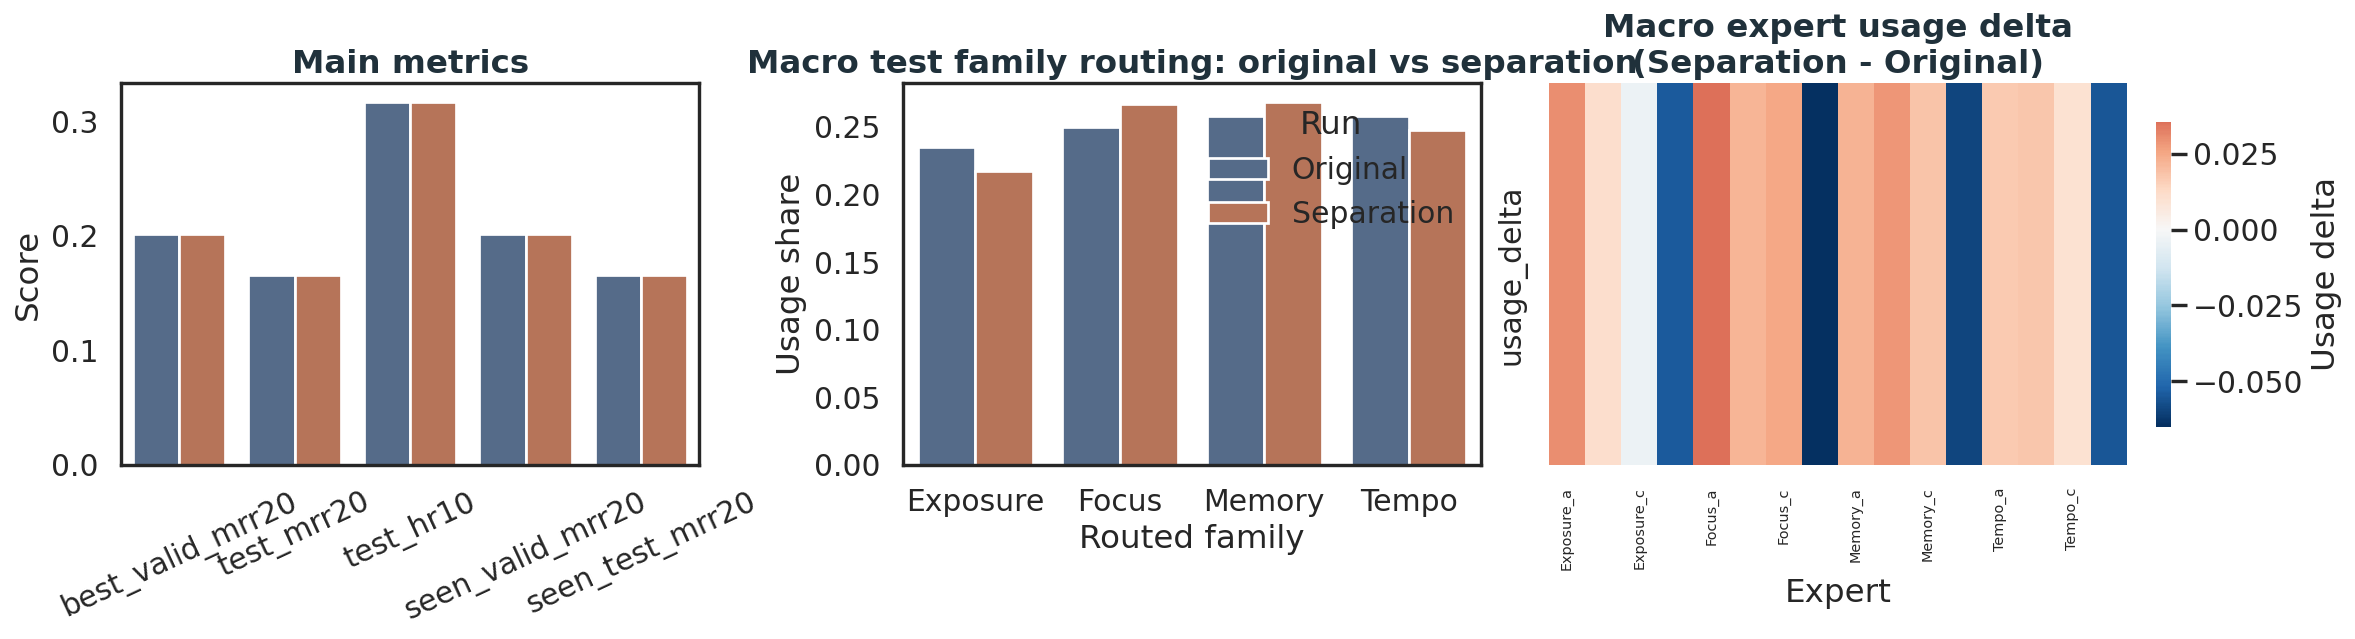

,label,status,test_mrr20,test_seen_mrr20
0,original,ok,0.116540,0.165867
1,permissive_union,ok,0.154449,0.220299
2,permissive__exposure_minus,ok,0.134174,0.193080
3,permissive__exposure_plus,ok,0.237144,0.286363
4,permissive__focus_minus,ok,0.115761,0.178523
5,permissive__focus_plus,ok,0.168099,0.227868
6,permissive__memory_minus,ok,0.084505,0.124330
7,permissive__memory_plus,ok,0.211019,0.282149
8,permissive__tempo_minus,ok,0.240380,0.294057
9,permissive__tempo_plus,ok,0.097700,0.169153


,value
far_same_gate_sep_loss,0.05
near_same_gate_sep_loss,0.00
far_diff_gate_sep_loss,0.00


In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

base_result_path = REPO_ROOT / 'experiments' / 'run' / 'artifacts' / 'results' / 'fmoe_n4' / 'foursquare_FeaturedMoE_N3_p4xd_xd_foursquare_f20_h3_midaux_probe_s1_20260416_035403_601895_pid249461.json'
sep_result_path = REPO_ROOT / 'experiments' / 'run' / 'artifacts' / 'results' / 'fmoe_n4' / 'foursquare_FeaturedMoE_N3_p4x2_xd_fsq_f20_h3_midaux_sep2_v4_s1_20260420_155155_833565_pid1342802.json'
base_case_tables = REPO_ROOT / 'experiments' / 'run' / 'artifacts' / 'logs' / 'real_final_ablation' / 'q5' / 'case_eval_rerun' / 'Q5_FOURSQUARE_BEHAVIOR_GUIDED_R01_S1_FILTERFIX_20260420' / 'tables'
sep_case_tables = REPO_ROOT / 'experiments' / 'run' / 'artifacts' / 'logs' / 'real_final_ablation' / 'q5' / 'case_eval_rerun' / 'Q5_FOURSQUARE_ROUTE_SEPARATION_P4X2_F20_H3_SEP2_V4_S1_CFG4' / 'tables'
sep_loss_probe_path = REPO_ROOT / 'experiments' / 'run' / 'artifacts' / 'logs' / 'real_final_ablation' / 'q5' / 'case_eval_rerun' / 'route_separation_unit_probe.json'

base_payload = pd.read_json(base_result_path, typ='series')
sep_payload = pd.read_json(sep_result_path, typ='series')
base_trial = (base_payload['trials'][-1] if 'trials' in base_payload and len(base_payload['trials']) else {})
sep_trial = (sep_payload['trials'][-1] if 'trials' in sep_payload and len(sep_payload['trials']) else {})
base_stage = pd.Series(base_trial).filter(regex=r'^macro_1\.')
sep_stage = pd.Series(sep_trial).filter(regex=r'^macro_1\.')

perf_compare = pd.DataFrame([
    {
        'run': 'Original F20 midaux probe',
        'best_valid_mrr20': float(base_payload.get('best_mrr@20', float('nan'))),
        'test_mrr20': float(base_payload.get('test_mrr@20', float('nan'))),
        'test_hr10': float(base_payload.get('test_hr@10', float('nan'))),
        'seen_valid_mrr20': float((base_payload.get('best_valid_special_metrics') or {}).get('overall_seen_target', {}).get('mrr@20', float('nan'))),
        'seen_test_mrr20': float((base_payload.get('test_special_metrics') or {}).get('overall_seen_target', {}).get('mrr@20', float('nan'))),
        'macro_entropy_mean': float(base_stage.get('macro_1.entropy_mean', float('nan'))),
        'macro_n_eff': float(base_stage.get('macro_1.n_eff', float('nan'))),
        'macro_group_n_eff': float(base_stage.get('macro_1.group_n_eff', float('nan'))),
        'route_consistency_feature_group_mean': float(base_stage.get('macro_1.route_consistency_feature_group_knn_mean_score', float('nan'))),
    },
    {
        'run': 'Separation probe',
        'best_valid_mrr20': float(sep_payload.get('best_mrr@20', float('nan'))),
        'test_mrr20': float(sep_payload.get('test_mrr@20', float('nan'))),
        'test_hr10': float(sep_payload.get('test_hr@10', float('nan'))),
        'seen_valid_mrr20': float((sep_payload.get('best_valid_special_metrics') or {}).get('overall_seen_target', {}).get('mrr@20', float('nan'))),
        'seen_test_mrr20': float((sep_payload.get('test_special_metrics') or {}).get('overall_seen_target', {}).get('mrr@20', float('nan'))),
        'macro_entropy_mean': float(sep_stage.get('macro_1.entropy_mean', float('nan'))),
        'macro_n_eff': float(sep_stage.get('macro_1.n_eff', float('nan'))),
        'macro_group_n_eff': float(sep_stage.get('macro_1.group_n_eff', float('nan'))),
        'route_consistency_feature_group_mean': float(sep_stage.get('macro_1.route_consistency_feature_group_knn_mean_score', float('nan'))),
    },
])
perf_delta = perf_compare.set_index('run').diff().tail(1)
perf_delta.index = ['Separation - Original']
display(perf_compare)
display(perf_delta)

base_routing = pd.read_csv(base_case_tables / 'case_eval_routing_profile.csv')
sep_routing = pd.read_csv(sep_case_tables / 'case_eval_routing_profile.csv')
base_expert = pd.read_csv(base_case_tables / 'case_eval_expert_profile.csv')
sep_expert = pd.read_csv(sep_case_tables / 'case_eval_expert_profile.csv')
base_perf = pd.read_csv(base_case_tables / 'case_eval_performance.csv')
sep_perf = pd.read_csv(sep_case_tables / 'case_eval_performance.csv')
sep_loss_probe = pd.read_json(sep_loss_probe_path, typ='series') if sep_loss_probe_path.exists() else pd.Series(dtype=float)

base_original_macro = base_routing.loc[
    (base_routing['label'] == 'original')
    & (base_routing['eval_split'] == 'test')
    & (base_routing['stage_name'] == 'macro')
].copy()
sep_original_macro = sep_routing.loc[
    (sep_routing['label'] == 'original')
    & (sep_routing['eval_split'] == 'test')
    & (sep_routing['stage_name'] == 'macro')
].copy()

family_panel = (
    base_original_macro[['routed_family', 'usage_share']]
    .rename(columns={'usage_share': 'Original'})
    .merge(
        sep_original_macro[['routed_family', 'usage_share']].rename(columns={'usage_share': 'Separation'}),
        on='routed_family',
        how='outer',
    )
    .fillna(0.0)
)
family_panel['delta'] = family_panel['Separation'] - family_panel['Original']
family_panel['routed_family'] = pd.Categorical(family_panel['routed_family'], categories=['Exposure', 'Focus', 'Memory', 'Tempo'], ordered=True)
family_panel = family_panel.sort_values('routed_family').reset_index(drop=True)
display(family_panel)

base_original_expert = base_expert.loc[
    (base_expert['label'] == 'original')
    & (base_expert['eval_split'] == 'test')
    & (base_expert['stage_name'] == 'macro')
].copy()
sep_original_expert = sep_expert.loc[
    (sep_expert['label'] == 'original')
    & (sep_expert['eval_split'] == 'test')
    & (sep_expert['stage_name'] == 'macro')
].copy()

expert_panel = (
    base_original_expert[['expert_name', 'top1_count', 'usage_share']]
    .rename(columns={'top1_count': 'Original_top1', 'usage_share': 'Original_usage'})
    .merge(
        sep_original_expert[['expert_name', 'top1_count', 'usage_share']].rename(columns={'top1_count': 'Separation_top1', 'usage_share': 'Separation_usage'}),
        on='expert_name',
        how='outer',
    )
    .fillna(0.0)
)
expert_panel['top1_delta'] = expert_panel['Separation_top1'] - expert_panel['Original_top1']
expert_panel['usage_delta'] = expert_panel['Separation_usage'] - expert_panel['Original_usage']
expert_panel['expert_family'] = expert_panel['expert_name'].str.split('_').str[0].str.title()
expert_panel = expert_panel.sort_values(['expert_family', 'expert_name']).reset_index(drop=True)
display(expert_panel.head(12))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

metric_plot_df = perf_compare.melt(
    id_vars='run',
    value_vars=['best_valid_mrr20', 'test_mrr20', 'test_hr10', 'seen_valid_mrr20', 'seen_test_mrr20'],
    var_name='metric',
    value_name='value',
)
sns.barplot(data=metric_plot_df, x='metric', y='value', hue='run', ax=axes[0], palette=['#4C6A92', '#C56E4A'])
axes[0].set_title('Main metrics')
axes[0].set_xlabel('')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=25)

family_plot_df = family_panel.melt(id_vars='routed_family', value_vars=['Original', 'Separation'], var_name='run', value_name='usage_share')
sns.barplot(data=family_plot_df, x='routed_family', y='usage_share', hue='run', ax=axes[1], palette=['#4C6A92', '#C56E4A'])
axes[1].set_title('Macro test family routing: original vs separation')
axes[1].set_xlabel('Routed family')
axes[1].set_ylabel('Usage share')
axes[1].tick_params(axis='x', rotation=0)

expert_delta_heat = expert_panel.set_index('expert_name')[['usage_delta']].T
sns.heatmap(expert_delta_heat, cmap='RdBu_r', center=0.0, ax=axes[2], cbar_kws={'shrink': 0.8, 'label': 'Usage delta'})
axes[2].set_title('Macro expert usage delta\n(Separation - Original)')
axes[2].set_xlabel('Expert')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=90, labelsize=8)

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend(handles, labels, title='Run', loc='best')
plt.show()

sep_case_summary = sep_perf.loc[:, ['label', 'status', 'test_mrr20', 'test_seen_mrr20']].copy()
display(sep_case_summary.head(10))
if not sep_loss_probe.empty:
    display(sep_loss_probe.to_frame(name='value'))

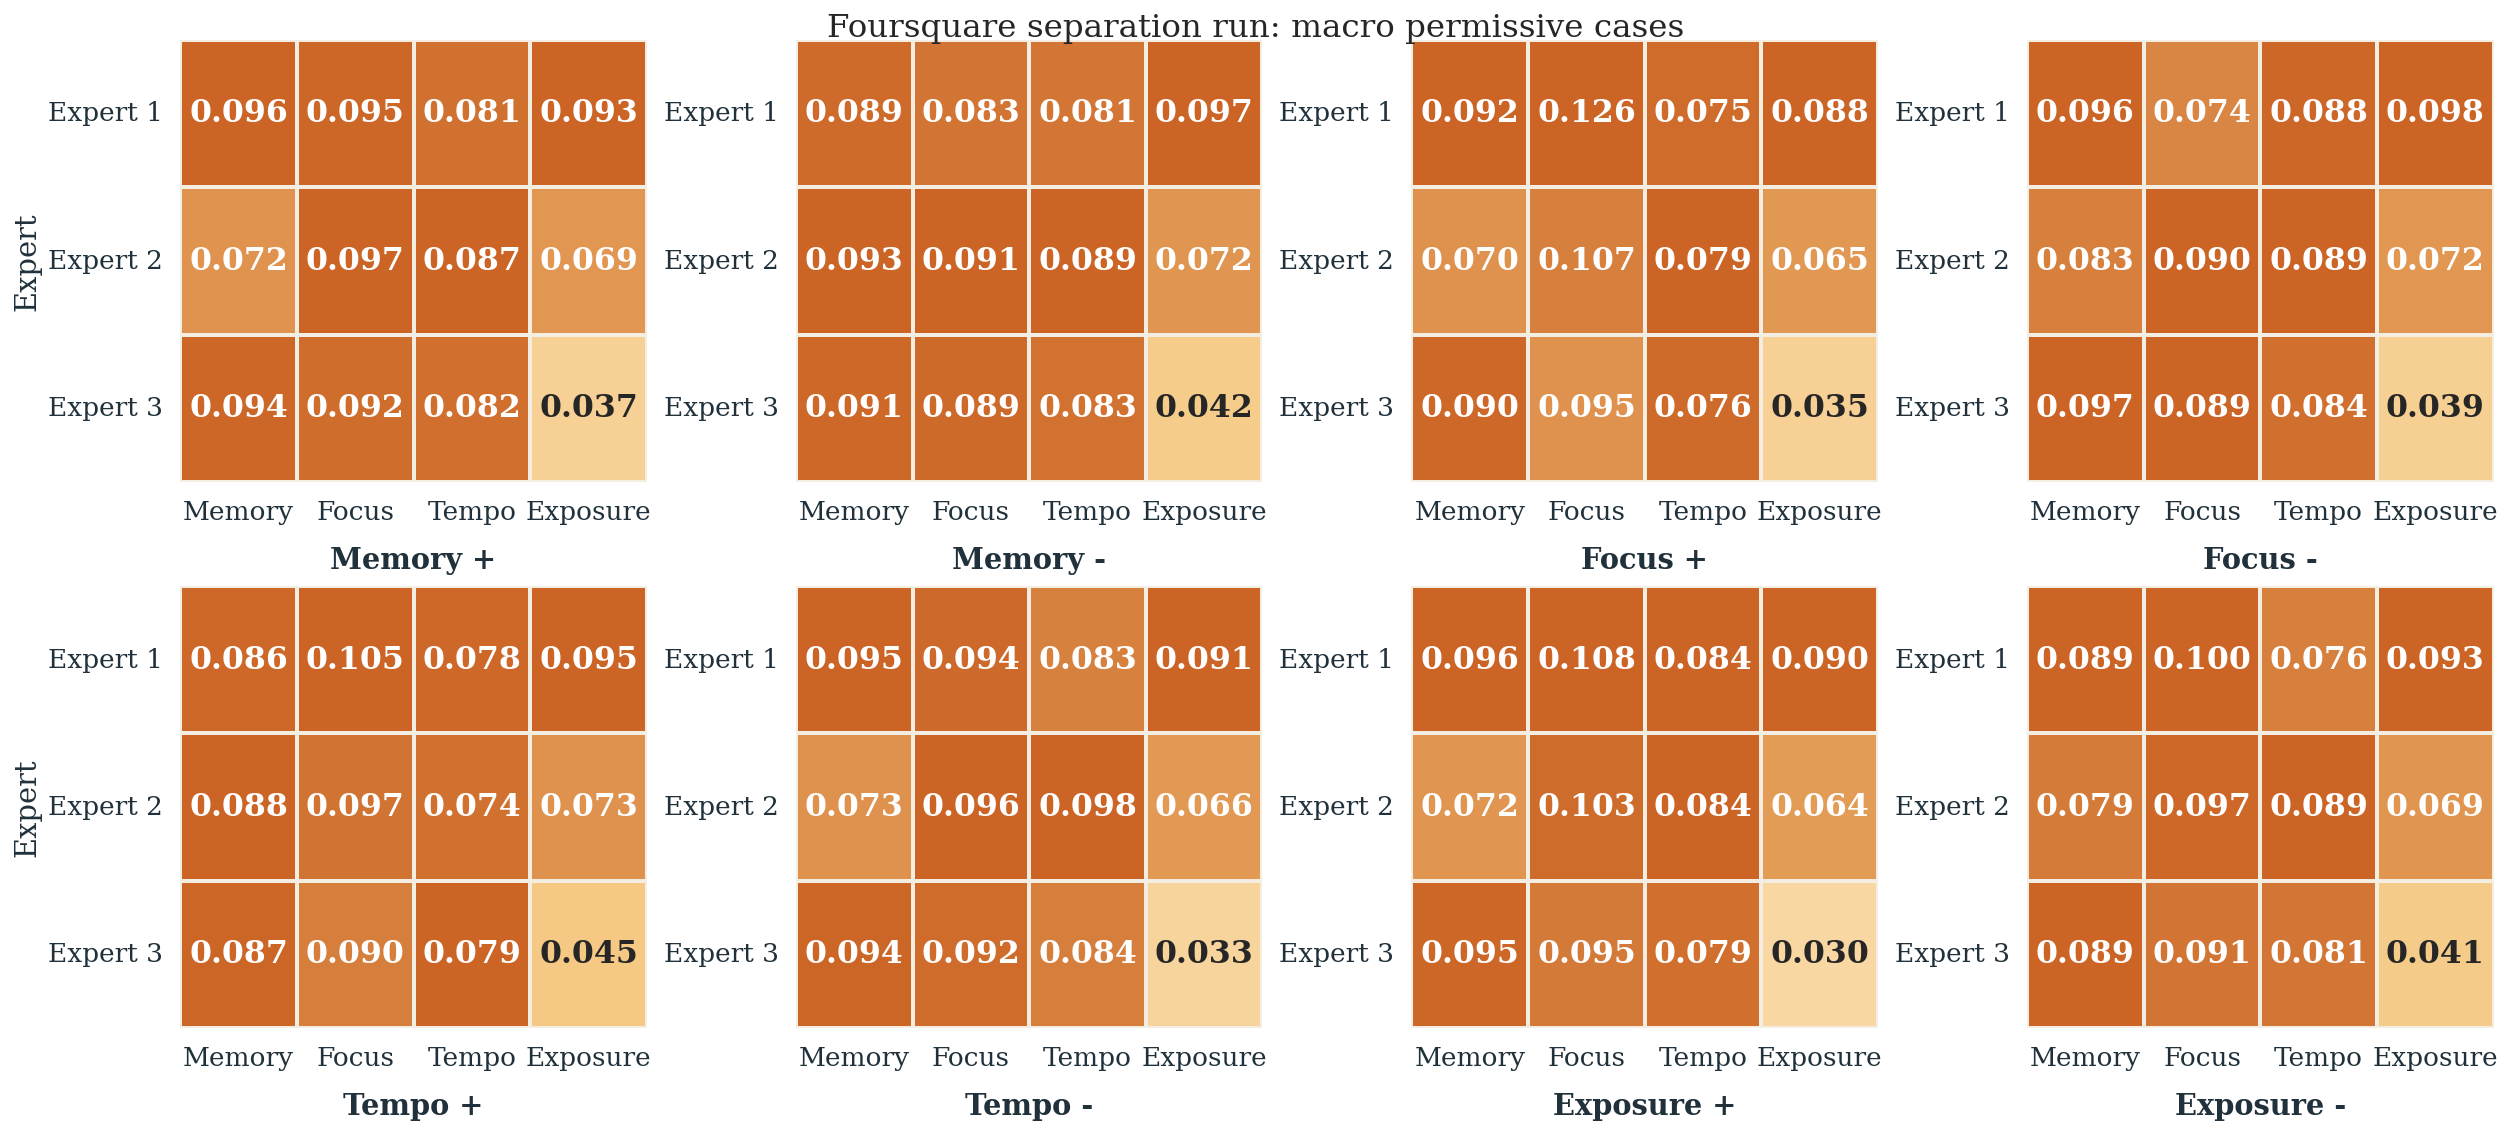

,display_name,expert_l1_from_original,macro_group_l1
0,Memory +,0.069581,0.040955
1,Memory -,0.023315,0.013775
2,Focus +,0.130371,0.129853
3,Focus -,0.055382,0.041367
4,Tempo +,0.060215,0.055941
5,Tempo -,0.079746,0.063566
6,Exposure +,0.116959,0.084112
7,Exposure -,0.049463,0.048751


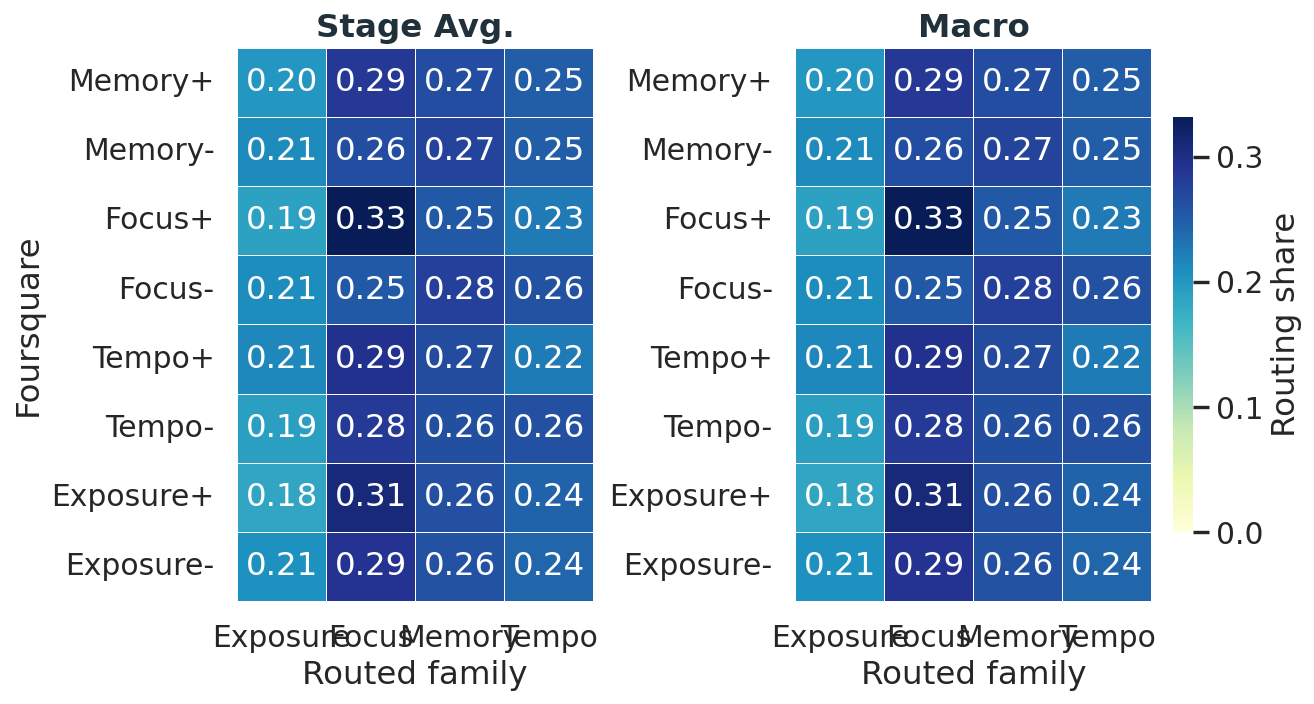

,case_label,target_stage_avg_share,macro,test_seen_mrr20
0,Focus+,0.331673,0.331673,0.227868
1,Memory-,0.273902,0.273902,0.124330
2,Memory+,0.265419,0.265419,0.282149
3,Tempo-,0.261895,0.261895,0.294057
4,Focus-,0.253514,0.253514,0.178523
5,Tempo+,0.224537,0.224537,0.169153
6,Exposure-,0.206105,0.206105,0.193080
7,Exposure+,0.184524,0.184524,0.286363


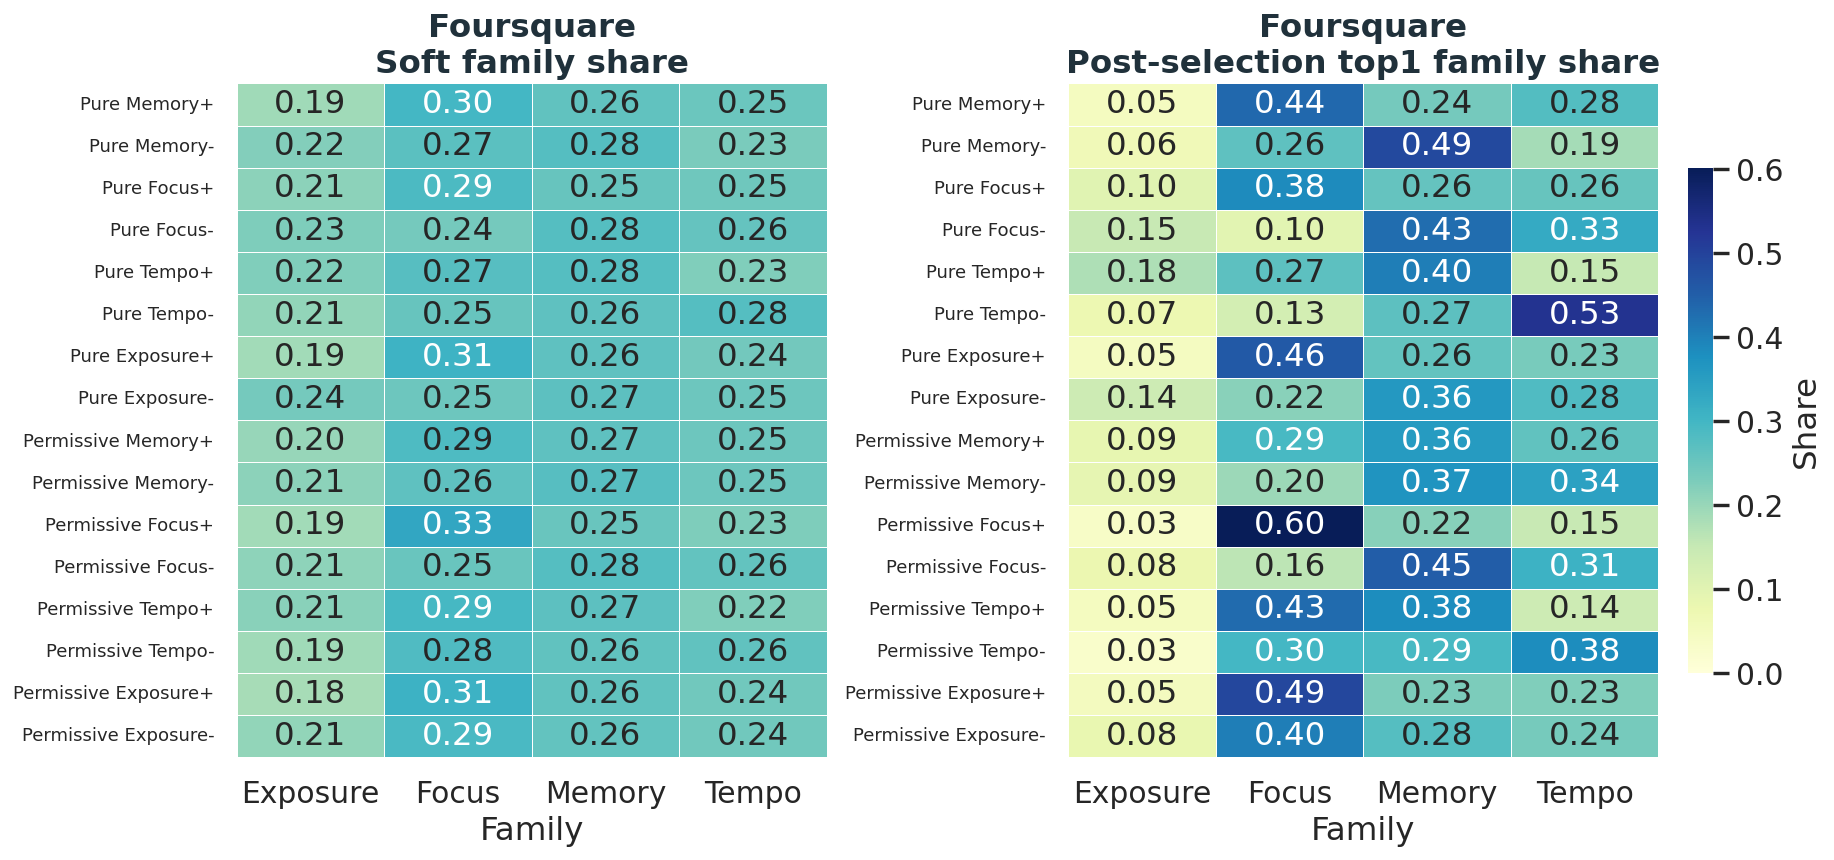

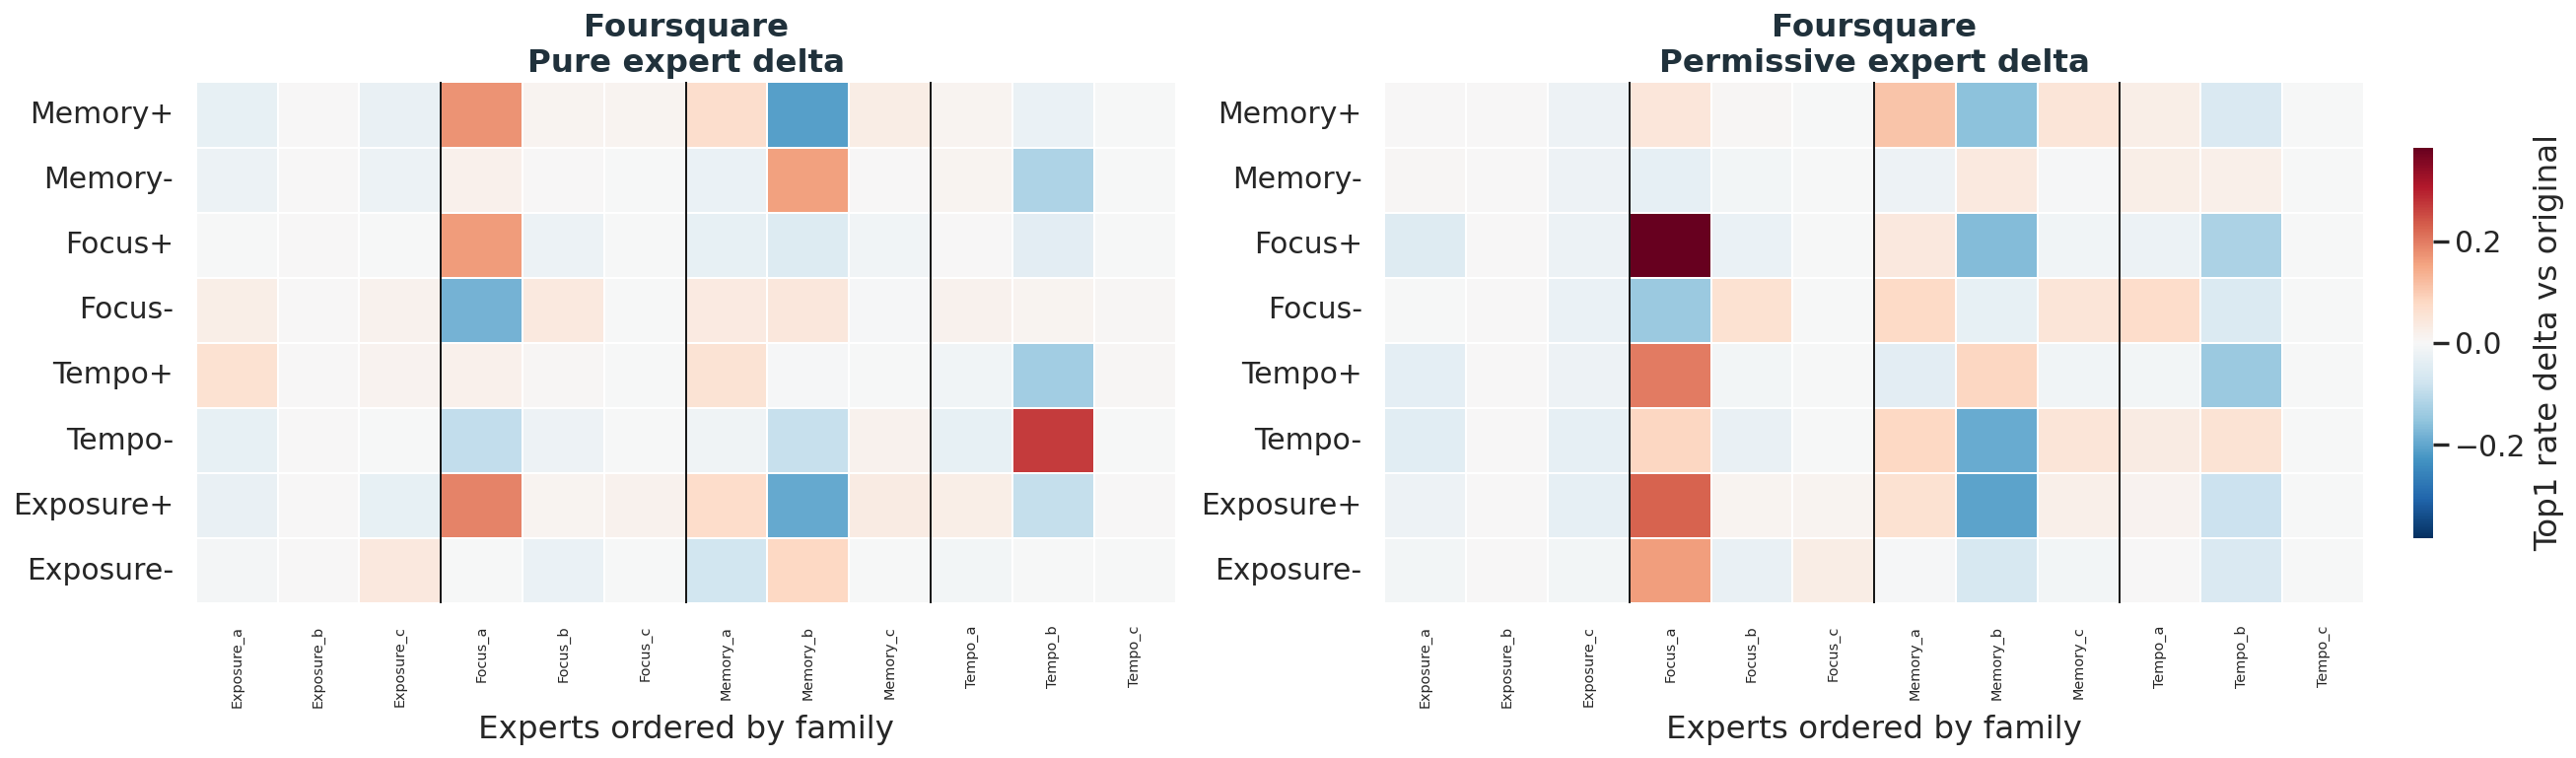

,tier_label,case_label,soft_target_share,top1_target_share,target_gain_top1_minus_soft,total_top1_assignments,test_seen_mrr20,test_seen_ndcg20,test_seen_hit10
0,Permissive,Memory+,0.265419,0.356287,0.090868,668.0,0.282149,0.352803,0.483146
1,Permissive,Memory-,0.273902,0.369792,0.095890,576.0,0.124330,0.162578,0.275862
2,Permissive,Focus+,0.331673,0.601896,0.270223,633.0,0.227868,0.281674,0.433333
3,Permissive,Focus-,0.253514,0.160638,-0.092876,940.0,0.178523,0.254918,0.433735
4,Permissive,Tempo+,0.224537,0.139303,-0.085233,402.0,0.169153,0.231221,0.388060
5,Permissive,Tempo-,0.261895,0.382746,0.120851,823.0,0.294057,0.361749,0.553398
6,Permissive,Exposure+,0.184524,0.051322,-0.133202,1286.0,0.286363,0.367909,0.566038
7,Permissive,Exposure-,0.206105,0.084317,-0.121788,593.0,0.193080,0.241793,0.378049
8,Pure,Memory+,0.261218,0.238730,-0.022488,1575.0,0.331371,0.398389,0.577922
9,Pure,Memory-,0.276685,0.487662,0.210977,1540.0,0.188485,0.238920,0.340909


Separation bundle: Q5_FOURSQUARE_ROUTE_SEPARATION_P4X2_F20_H3_SEP2_V4_S1_CFG4
Dataset: Foursquare
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_separation_macro_cases.png
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_separation_macro_cases.pdf
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_separation_permissive_stage_grid.png
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_separation_permissive_stage_grid.pdf
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_separation_soft_vs_top1_family.png
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_separation_soft_vs_top1_family.pdf
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_separation_expert_top1_delta.png
/workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a05_foursquare_separation_expert_top1_delta.pdf
/workspace/FeaturedMoE/writing

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sep_q5_tables = sep_case_tables if 'sep_case_tables' in globals() else (
    REPO_ROOT
    / 'experiments'
    / 'run'
    / 'artifacts'
    / 'logs'
    / 'real_final_ablation'
    / 'q5'
    / 'case_eval_rerun'
    / 'Q5_FOURSQUARE_ROUTE_SEPARATION_P4X2_F20_H3_SEP2_V4_S1_CFG4'
    / 'tables'
 )
sep_q5_bundle_name = sep_q5_tables.parent.name
sep_q5_appendix_dir = Q5_APPENDIX_DIR if 'Q5_APPENDIX_DIR' in globals() else (REPO_ROOT / 'writing' / 'ACM_template' / 'figures' / 'appendix')
sep_q5_generated_dir = Q5_GENERATED_DIR if 'Q5_GENERATED_DIR' in globals() else (REPO_ROOT / 'writing' / '260419_real_final_exp' / 'generated')
sep_q5_appendix_dir.mkdir(parents=True, exist_ok=True)
sep_q5_generated_dir.mkdir(parents=True, exist_ok=True)

sep_q5_routing = pd.read_csv(sep_q5_tables / 'case_eval_routing_profile.csv').copy()
sep_q5_expert = pd.read_csv(sep_q5_tables / 'case_eval_expert_profile.csv').copy()
sep_q5_perf = pd.read_csv(sep_q5_tables / 'case_eval_performance.csv').copy()

for frame in [sep_q5_routing, sep_q5_expert, sep_q5_perf]:
    for col in ['scope', 'tier', 'selected_family', 'selected_polarity', 'label', 'eval_split', 'stage_name']:
        if col in frame.columns:
            frame[col] = frame[col].astype(str).str.lower()
    if 'routed_family' in frame.columns:
        frame['routed_family'] = frame['routed_family'].astype(str).str.title()
    if 'expert_family' in frame.columns:
        frame['expert_family'] = frame['expert_family'].astype(str).str.lower()

sep_q5_dataset = str(sep_q5_routing['dataset'].dropna().iloc[0])
sep_q5_dataset_label = Q5_DATASET_LABELS.get(sep_q5_dataset, DATASET_LABELS.get(sep_q5_dataset, sep_q5_dataset))
sep_q5_stage_order = [stage for stage in Q5_STAGE_ORDER if stage in set(sep_q5_routing['stage_name'].dropna().unique())]
sep_q5_tier_order = [tier for tier in Q5_TIER_ORDER if tier in set(sep_q5_routing['tier'].dropna().unique())]

if callable(globals().get('apply_style')):
    apply_style()

sep_macro_case_labels = available_macro_case_labels(sep_q5_dataset, sep_q5_bundle_name)
sep_macro_case_panels = {
    label: macro_fixed_panel(sep_q5_dataset, label, sep_q5_bundle_name)
    for label in sep_macro_case_labels
}
sep_macro_case_summary = macro_case_summary(sep_q5_dataset, sep_q5_bundle_name)

if sep_macro_case_labels:
    ncols = 4
    nrows = max(1, int(np.ceil(len(sep_macro_case_labels) / ncols)))
    fig_sep_macro, axes_sep_macro = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4.8, nrows * 4.2),
        constrained_layout=True,
    )
    axes_sep_macro = np.atleast_1d(axes_sep_macro).ravel()

    for idx, label in enumerate(sep_macro_case_labels):
        draw_compact_case_heatmap(
            axes_sep_macro[idx],
            sep_macro_case_panels[label],
            case_display_name(label),
            show_ylabel=(idx % ncols == 0),
            annot_size=17.5,
            label_size=16.0,
            tick_size=14.6,
        )

    for idx in range(len(sep_macro_case_labels), len(axes_sep_macro)):
        axes_sep_macro[idx].axis('off')

    fig_sep_macro.suptitle(
        f'{sep_q5_dataset_label} separation run: macro permissive cases',
        fontsize=18,
        y=1.02,
    )
    sep_macro_png = sep_q5_appendix_dir / 'a05_foursquare_separation_macro_cases.png'
    sep_macro_pdf = sep_q5_appendix_dir / 'a05_foursquare_separation_macro_cases.pdf'
    fig_sep_macro.savefig(sep_macro_png, dpi=220, bbox_inches='tight')
    fig_sep_macro.savefig(sep_macro_pdf, bbox_inches='tight')
    plt.show()
    display(sep_macro_case_summary[['display_name', 'expert_l1_from_original', 'macro_group_l1']])
else:
    print('No macro permissive case heatmaps found in separation bundle.')

sep_perm_routing = sep_q5_routing.loc[
    (sep_q5_routing['scope'] == 'tier_group')
    & (sep_q5_routing['tier'] == 'permissive')
    & (sep_q5_routing['status'] == 'ok')
    & (sep_q5_routing['eval_split'] == 'test')
    & sep_q5_routing['selected_family'].notna()
    & sep_q5_routing['selected_polarity'].notna()
].copy()
sep_perm_routing['case_key'] = sep_perm_routing['selected_family'] + '_' + sep_perm_routing['selected_polarity']
sep_perm_routing['case_label'] = sep_perm_routing['case_key'].map(Q5_CASE_LABELS_SHORT)

sep_perm_perf = sep_q5_perf.loc[
    (sep_q5_perf['scope'] == 'tier_group')
    & (sep_q5_perf['tier'] == 'permissive')
    & (sep_q5_perf['status'] == 'ok')
    & sep_q5_perf['selected_family'].notna()
    & sep_q5_perf['selected_polarity'].notna()
].copy()
sep_perm_perf['case_key'] = sep_perm_perf['selected_family'] + '_' + sep_perm_perf['selected_polarity']
sep_perm_perf['case_label'] = sep_perm_perf['case_key'].map(Q5_CASE_LABELS_SHORT)

sep_case_order = [case_key for case_key in Q5_CASE_ORDER if case_key in set(sep_perm_routing['case_key'].dropna())]
sep_case_labels = [Q5_CASE_LABELS_SHORT[case_key] for case_key in sep_case_order]

def sep_build_case_panel(frame, stage_key):
    if stage_key == 'avg':
        panel_df = frame.groupby(['case_label', 'routed_family'], as_index=False)['usage_share'].mean()
    else:
        panel_df = frame.loc[frame['stage_name'] == stage_key, ['case_label', 'routed_family', 'usage_share']].copy()
    panel = panel_df.pivot(index='case_label', columns='routed_family', values='usage_share')
    panel = panel.reindex(index=sep_case_labels, columns=Q5_FAMILY_ORDER)
    return panel.fillna(0.0)

if not sep_perm_routing.empty:
    sns.set_theme(style='white', context='talk')
    sep_stage_keys = ['avg', *sep_q5_stage_order]
    sep_grid_panels = {stage_key: sep_build_case_panel(sep_perm_routing, stage_key) for stage_key in sep_stage_keys}
    sep_grid_vmax = max(panel.to_numpy().max() for panel in sep_grid_panels.values())

    fig_sep_grid, axes_sep_grid = plt.subplots(
        1,
        len(sep_stage_keys),
        figsize=(5 * len(sep_stage_keys), 5.3),
        constrained_layout=True,
        squeeze=False,
    )
    for col_idx, stage_key in enumerate(sep_stage_keys):
        ax = axes_sep_grid[0, col_idx]
        panel = sep_grid_panels[stage_key]
        sns.heatmap(
            panel,
            ax=ax,
            cmap='YlGnBu',
            vmin=0,
            vmax=sep_grid_vmax,
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            linecolor='white',
            cbar=(col_idx == len(sep_stage_keys) - 1),
            cbar_kws={'shrink': 0.75, 'label': 'Routing share'},
        )
        ax.set_title(Q5_STAGE_TITLE.get(stage_key, stage_key.title()))
        ax.set_xlabel('Routed family')
        ax.set_ylabel(sep_q5_dataset_label if col_idx == 0 else '')
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0)

    sep_stage_png = sep_q5_appendix_dir / 'a05_foursquare_separation_permissive_stage_grid.png'
    sep_stage_pdf = sep_q5_appendix_dir / 'a05_foursquare_separation_permissive_stage_grid.pdf'
    fig_sep_grid.savefig(sep_stage_png, dpi=220, bbox_inches='tight')
    fig_sep_grid.savefig(sep_stage_pdf, bbox_inches='tight')
    plt.show()

    sep_target_stage_summary = (
        sep_perm_routing.loc[sep_perm_routing['selected_family'].str.title() == sep_perm_routing['routed_family']]
        .groupby(['case_key', 'case_label', 'stage_name'], as_index=False)['usage_share']
        .mean()
        .rename(columns={'usage_share': 'target_family_share'})
    )
    sep_stage_average_summary = (
        sep_target_stage_summary.groupby(['case_key', 'case_label'], as_index=False)['target_family_share']
        .mean()
        .rename(columns={'target_family_share': 'target_stage_avg_share'})
    )
    sep_stage_pivot = sep_target_stage_summary.pivot(index=['case_key', 'case_label'], columns='stage_name', values='target_family_share').reset_index()
    sep_stage_pivot.columns.name = None
    sep_sorted_summary = sep_stage_average_summary.merge(sep_stage_pivot, on=['case_key', 'case_label'], how='left').merge(
        sep_perm_perf[['case_key', 'case_label', 'test_seen_mrr20', 'test_seen_ndcg20', 'test_seen_hit10']].drop_duplicates(),
        on=['case_key', 'case_label'],
        how='left',
    )
    sep_sorted_summary['case_sort'] = pd.Categorical(sep_sorted_summary['case_key'], categories=sep_case_order, ordered=True)
    sep_sorted_summary = sep_sorted_summary.sort_values(['target_stage_avg_share', 'test_seen_mrr20'], ascending=[False, False]).reset_index(drop=True)
    display(sep_sorted_summary[['case_label', 'target_stage_avg_share', *sep_q5_stage_order, 'test_seen_mrr20']])
else:
    print('No permissive tier-group routing rows found in separation bundle.')

sep_top1_routing = sep_q5_routing.loc[
    (sep_q5_routing['status'] == 'ok')
    & (sep_q5_routing['scope'] == 'tier_group')
    & (sep_q5_routing['tier'].isin(sep_q5_tier_order))
    & (sep_q5_routing['eval_split'] == 'test')
    & (sep_q5_routing['stage_name'] == 'macro')
    & sep_q5_routing['selected_family'].notna()
    & sep_q5_routing['selected_polarity'].notna()
].copy()
sep_top1_routing['case_key'] = sep_top1_routing['selected_family'] + '_' + sep_top1_routing['selected_polarity']
sep_top1_routing['case_label'] = sep_top1_routing['case_key'].map(Q5_CASE_LABELS_SHORT)

sep_top1_expert = sep_q5_expert.loc[
    (sep_q5_expert['status'] == 'ok')
    & (sep_q5_expert['eval_split'] == 'test')
    & (sep_q5_expert['stage_name'] == 'macro')
    & (
        (sep_q5_expert['scope'] == 'original')
        | (
            (sep_q5_expert['scope'] == 'tier_group')
            & sep_q5_expert['tier'].isin(sep_q5_tier_order)
            & sep_q5_expert['selected_family'].notna()
            & sep_q5_expert['selected_polarity'].notna()
        )
    )
].copy()
sep_top1_expert['case_key'] = sep_top1_expert['selected_family'] + '_' + sep_top1_expert['selected_polarity']
sep_top1_expert['case_label'] = sep_top1_expert['case_key'].map(Q5_CASE_LABELS_SHORT)

sep_top1_perf = sep_q5_perf.loc[
    (sep_q5_perf['status'] == 'ok')
    & (sep_q5_perf['scope'] == 'tier_group')
    & (sep_q5_perf['tier'].isin(sep_q5_tier_order))
    & sep_q5_perf['selected_family'].notna()
    & sep_q5_perf['selected_polarity'].notna()
].copy()
sep_top1_perf['case_key'] = sep_top1_perf['selected_family'] + '_' + sep_top1_perf['selected_polarity']
sep_top1_perf['case_label'] = sep_top1_perf['case_key'].map(Q5_CASE_LABELS_SHORT)

sep_original_expert = sep_top1_expert.loc[sep_top1_expert['scope'] == 'original'].copy()
sep_original_expert['original_total_top1'] = sep_original_expert.groupby('dataset')['top1_count'].transform('sum')
sep_original_expert['original_top1_rate'] = sep_original_expert['top1_count'] / sep_original_expert['original_total_top1']
sep_original_expert_rate = sep_original_expert[['dataset', 'expert_name', 'expert_family', 'original_top1_rate']].drop_duplicates()
sep_expert_order = sep_original_expert.sort_values(['expert_family', 'expert_index'])['expert_name'].tolist()
sep_expert_family_lookup = sep_original_expert[['expert_name', 'expert_family']].drop_duplicates().set_index('expert_name')['expert_family']

sep_case_expert = sep_top1_expert.loc[sep_top1_expert['scope'] == 'tier_group'].copy()
sep_case_expert['total_top1_count'] = sep_case_expert.groupby(['dataset', 'tier', 'case_key'])['top1_count'].transform('sum')
sep_case_expert['top1_rate'] = sep_case_expert['top1_count'] / sep_case_expert['total_top1_count']
sep_case_expert = sep_case_expert.merge(
    sep_original_expert_rate,
    on=['dataset', 'expert_name', 'expert_family'],
    how='left',
 )
sep_case_expert['top1_delta_vs_original'] = sep_case_expert['top1_rate'] - sep_case_expert['original_top1_rate']
sep_case_expert['tier_case_label'] = sep_case_expert['tier'].map(Q5_TIER_LABELS) + ' ' + sep_case_expert['case_label']

sep_soft_family = sep_top1_routing[['dataset', 'tier', 'case_key', 'case_label', 'selected_family', 'routed_family', 'usage_share']].copy()
sep_soft_family['tier_case_label'] = sep_soft_family['tier'].map(Q5_TIER_LABELS) + ' ' + sep_soft_family['case_label']
sep_soft_family['family'] = sep_soft_family['routed_family']

sep_top1_family = (
    sep_case_expert.groupby(['dataset', 'tier', 'case_key', 'case_label', 'selected_family', 'expert_family'], as_index=False)['top1_rate']
    .sum()
    .rename(columns={'expert_family': 'family', 'top1_rate': 'top1_family_share'})
)
sep_top1_family['family'] = sep_top1_family['family'].str.title()
sep_top1_family['tier_case_label'] = sep_top1_family['tier'].map(Q5_TIER_LABELS) + ' ' + sep_top1_family['case_label']

sep_metric_order = [
    f"{Q5_TIER_LABELS[tier]} {Q5_CASE_LABELS_SHORT[case_key]}"
    for tier in sep_q5_tier_order
    for case_key in Q5_CASE_ORDER
    if case_key in set(sep_top1_family['case_key'].dropna())
]

def sep_build_metric_panel(frame, value_col):
    panel = frame.pivot(index='tier_case_label', columns='family', values=value_col)
    panel = panel.reindex(index=sep_metric_order, columns=Q5_FAMILY_ORDER)
    return panel

if not sep_top1_family.empty and not sep_soft_family.empty:
    sep_soft_panel = sep_build_metric_panel(sep_soft_family, 'usage_share')
    sep_top1_panel = sep_build_metric_panel(sep_top1_family, 'top1_family_share')
    sep_family_vmax = max(sep_soft_panel.to_numpy().max(), sep_top1_panel.to_numpy().max())

    fig_sep_family, axes_sep_family = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
    for ax, panel, title in [
        (axes_sep_family[0], sep_soft_panel, 'Soft family share'),
        (axes_sep_family[1], sep_top1_panel, 'Post-selection top1 family share'),
    ]:
        sns.heatmap(
            panel,
            ax=ax,
            cmap='YlGnBu',
            vmin=0,
            vmax=sep_family_vmax,
            annot=True,
            fmt='.2f',
            linewidths=0.4,
            linecolor='white',
            cbar=ax is axes_sep_family[1],
            cbar_kws={'shrink': 0.75, 'label': 'Share'},
        )
        ax.set_title(f'{sep_q5_dataset_label}\n{title}')
        ax.set_xlabel('Family')
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=0)
        ax.tick_params(axis='y', rotation=0, labelsize=10)

    sep_family_png = sep_q5_appendix_dir / 'a05_foursquare_separation_soft_vs_top1_family.png'
    sep_family_pdf = sep_q5_appendix_dir / 'a05_foursquare_separation_soft_vs_top1_family.pdf'
    fig_sep_family.savefig(sep_family_png, dpi=220, bbox_inches='tight')
    fig_sep_family.savefig(sep_family_pdf, bbox_inches='tight')
    plt.show()

    sep_expert_delta_panels = {}
    for tier in sep_q5_tier_order:
        sub = sep_case_expert.loc[sep_case_expert['tier'] == tier].copy()
        panel = sub.pivot(index='case_label', columns='expert_name', values='top1_delta_vs_original')
        panel = panel.reindex(
            index=[Q5_CASE_LABELS_SHORT[key] for key in Q5_CASE_ORDER if key in set(sub['case_key'].dropna())],
            columns=sep_expert_order,
        )
        sep_expert_delta_panels[tier] = panel

    sep_expert_absmax = max(panel.abs().to_numpy().max() for panel in sep_expert_delta_panels.values())
    fig_sep_expert, axes_sep_expert = plt.subplots(
        1,
        len(sep_q5_tier_order),
        figsize=(10 * len(sep_q5_tier_order), 5.8),
        constrained_layout=True,
        squeeze=False,
    )
    family_sequence = [sep_expert_family_lookup[expert] for expert in sep_expert_order]
    boundary_positions = [
        idx
        for idx in range(1, len(family_sequence))
        if family_sequence[idx] != family_sequence[idx - 1]
    ]
    for col_idx, tier in enumerate(sep_q5_tier_order):
        ax = axes_sep_expert[0, col_idx]
        panel = sep_expert_delta_panels[tier]
        sns.heatmap(
            panel,
            ax=ax,
            cmap='RdBu_r',
            center=0,
            vmin=-sep_expert_absmax,
            vmax=sep_expert_absmax,
            linewidths=0.25,
            linecolor='white',
            cbar=(col_idx == len(sep_q5_tier_order) - 1),
            cbar_kws={'shrink': 0.75, 'label': 'Top1 rate delta vs original'},
        )
        for boundary in boundary_positions:
            ax.axvline(boundary, color='black', linewidth=1.0)
        ax.set_title(f'{sep_q5_dataset_label}\n{Q5_TIER_LABELS[tier]} expert delta')
        ax.set_xlabel('Experts ordered by family')
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=90, labelsize=8)
        ax.tick_params(axis='y', rotation=0)

    sep_expert_png = sep_q5_appendix_dir / 'a05_foursquare_separation_expert_top1_delta.png'
    sep_expert_pdf = sep_q5_appendix_dir / 'a05_foursquare_separation_expert_top1_delta.pdf'
    fig_sep_expert.savefig(sep_expert_png, dpi=220, bbox_inches='tight')
    fig_sep_expert.savefig(sep_expert_pdf, bbox_inches='tight')
    plt.show()

    sep_support_summary = (
        sep_case_expert.groupby(['dataset', 'tier', 'case_key', 'case_label'], as_index=False)['total_top1_count']
        .max()
    )
    sep_soft_target = sep_soft_family.loc[
        sep_soft_family['family'].str.lower() == sep_soft_family['selected_family']
    ].rename(columns={'usage_share': 'soft_target_share'})[['dataset', 'tier', 'case_key', 'case_label', 'soft_target_share']]
    sep_top1_target = sep_top1_family.loc[
        sep_top1_family['family'].str.lower() == sep_top1_family['selected_family']
    ].rename(columns={'top1_family_share': 'top1_target_share'})[['dataset', 'tier', 'case_key', 'case_label', 'top1_target_share']]
    sep_compare_summary = (
        sep_top1_perf[['dataset', 'tier', 'case_key', 'case_label', 'test_seen_mrr20', 'test_seen_ndcg20', 'test_seen_hit10']]
        .drop_duplicates()
        .merge(sep_support_summary, on=['dataset', 'tier', 'case_key', 'case_label'], how='left')
        .merge(sep_soft_target, on=['dataset', 'tier', 'case_key', 'case_label'], how='left')
        .merge(sep_top1_target, on=['dataset', 'tier', 'case_key', 'case_label'], how='left')
    )
    sep_compare_summary['target_gain_top1_minus_soft'] = sep_compare_summary['top1_target_share'] - sep_compare_summary['soft_target_share']
    sep_compare_summary['tier_label'] = sep_compare_summary['tier'].map(Q5_TIER_LABELS)
    sep_compare_summary['case_sort'] = pd.Categorical(sep_compare_summary['case_key'], categories=Q5_CASE_ORDER, ordered=True)
    sep_compare_summary = sep_compare_summary.sort_values(['tier_label', 'case_sort']).reset_index(drop=True)

    sep_compare_export = sep_compare_summary[
        ['tier_label', 'case_label', 'soft_target_share', 'top1_target_share', 'target_gain_top1_minus_soft', 'total_top1_count', 'test_seen_mrr20', 'test_seen_ndcg20', 'test_seen_hit10']
    ].rename(columns={'total_top1_count': 'total_top1_assignments'})
    sep_compare_csv = sep_q5_generated_dir / 'q5_separation_soft_vs_top1_summary.csv'
    sep_compare_md = sep_q5_generated_dir / 'q5_separation_soft_vs_top1_summary.md'
    sep_compare_export.to_csv(sep_compare_csv, index=False)
    sep_compare_md.write_text(sep_compare_export.to_markdown(index=False) + '\n', encoding='utf-8')
    display(sep_compare_export)
else:
    print('No macro top1 family/expert comparison rows found in separation bundle.')

print('Separation bundle:', sep_q5_bundle_name)
print('Dataset:', sep_q5_dataset_label)
for name in ['sep_macro_png', 'sep_macro_pdf', 'sep_stage_png', 'sep_stage_pdf', 'sep_family_png', 'sep_family_pdf', 'sep_expert_png', 'sep_expert_pdf', 'sep_compare_csv', 'sep_compare_md']:
    if name in globals():
        print(globals()[name])